# Rate numerics for the kernel moment–SoS hierarchy

What the hierarchy actually does as the relaxation order $n$ grows at fixed truncation order $d$, and along the
coupling $d(n)$ of R3, to calibrate the rate theorem
$f^\star-\lambda_{d,n}\le \|q\|\varepsilon_d(\text{localised})+K(p,d,\mathcal X)\,\mathrm{range}(P_d)/n^2$,
$P_d=q-f^\star_d\theta_d$.

**Setting.** Gaussian weight, $f=\omega^2q$, $\theta_d=\sum_{k\le d}\|x\|^{2k}/k!$,
$\lambda_{d,n}=\sup\{\lambda: q-\lambda\theta_d\in Q_n(\mathcal X)\}=\rho_{d,n}$, $Q_n$ the degree-$2n$ Putinar module of the listed
description (`Q`); `T` = the same description plus the product of the two box (or all simplex) constraints, which contains
the truncated preordering; `std` = the standard Lasserre bound of $P_d$ ($\theta\equiv1$), whose gap is the quantity the
effective Positivstellensätze bound.

**Solver.** The SDPs are written in a tensor Chebyshev basis of the bounding box (an exact change of basis of $Q_n$;
it keeps moment and Gram matrices of order one at degree $2n=32$) and solved by a primal–dual interior-point method
with Schur complement (Nesterov–Todd and HKM directions, Mehrotra predictor–corrector), written below in numpy.
Clarabel (dense PSD blocks in its KKT system) cannot reach $n\ge 12$ in 2-D and SCS does not reach the needed
accuracy; both are used as cross-checks at small sizes (Section 7). Each value is a **bracket**:
`lo` = $\lambda$ of a Gram certificate made PSD, minus $\|{\rm residual}\|_1\ge\sup_{\mathcal X}|{\rm residual}|$ (so $f^\star_d\ge$ and
$\lambda_{d,n}\ge$ `lo` rigorously up to rounding in the evaluation), `hi` = $L_y(q)$ for a moment vector $y$, $L_y(\theta_d)=1$, whose moment
and localising matrices are checked PSD (so $\rho_{d,n}\le$ `hi`). Three IPM variants are run when needed and the brackets intersected.
Gaps are reported as $[f^\star_d-\text{hi},\,f^\star_d-\text{lo}]$; a single number means a bracket narrower than 2%; `<1e-8`
means exact to the floating-point floor.

**Reproducibility.** `RECOMPUTE=False` loads the cached JSON results in `bench_rate_results/` (written by exactly this code, run
as a script in parallel); set `RECOMPUTE=True` to recompute everything (about 1.5 h on 10 cores). Section 2 recomputes a
few entries live and compares them with the cache.

In [1]:
import os, sys, json, math, time, glob, itertools, warnings, platform
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import cvxpy as cp
print("python", platform.python_version(), "| numpy", np.__version__, "| scipy", scipy.__version__, "| cvxpy", cp.__version__,
      "| solvers", cp.installed_solvers())
RECOMPUTE = False

python 3.13.3 | numpy 2.3.3 | scipy 1.16.1 | cvxpy 1.9.1 | solvers ['CLARABEL', 'SCS', 'SCIPY', 'HIGHS', 'OSQP']


## 1. Code
### 1a. Chebyshev algebra, operators, interior-point solver, reference minimisation

In [2]:
# rate_lib.py -- kernel moment-SoS hierarchy lambda_{d,n} in a Chebyshev basis, with a Schur-complement IPM.
# Self-contained (numpy/scipy only for the solver; cvxpy/Clarabel used only for cross-checks).
import itertools, math, time
import numpy as np
import scipy.sparse as sp
import scipy.linalg as sla
import scipy.signal as ssig
import scipy.optimize as so
from numpy.polynomial import chebyshev as Ch

# ============================================================ Gaussian weight
def a_k(k):
    return math.exp(-math.lgamma(k + 1))            # omega^{-2} = e^{|x|^2} = sum_k |x|^{2k}/k!

def theta_r(r, d):
    return sum(a_k(k) * r ** k for k in range(d + 1))

def pois_tail(r, d):
    # 1 - omega^2 theta_d at |x|^2 = r:  P(Pois(r) > d), without cancellation
    r = float(r)
    if r <= 0:
        return 0.0
    return math.fsum(math.exp(-r + k * math.log(r) - math.lgamma(k + 1)) for k in range(d + 1, d + 200))

# ============================================================ Chebyshev algebra on [-1,1]^p (dense arrays)
def _ext(A):
    # symmetric z-series extension along every axis: T_k -> (z^k + z^-k)/2
    for ax in range(A.ndim):
        K = A.shape[ax] - 1
        A = np.moveaxis(A, ax, 0)
        E = np.zeros((2 * K + 1,) + A.shape[1:])
        E[K] = A[0]
        E[K + 1:] = A[1:] / 2
        E[:K] = A[1:][::-1] / 2
        A = np.moveaxis(E, 0, ax)
    return A

def _fold(E):
    for ax in range(E.ndim):
        K = (E.shape[ax] - 1) // 2
        E = np.moveaxis(E, ax, 0)
        F = E[K:].copy()
        F[1:] *= 2
        E = np.moveaxis(F, 0, ax)
    return E

def cmul(A, B):
    return _fold(ssig.convolve(_ext(A), _ext(B), method="direct"))

def cadd(A, B):
    sh = tuple(max(a, b) for a, b in zip(A.shape, B.shape))
    C = np.zeros(sh)
    C[tuple(slice(0, s) for s in A.shape)] += A
    C[tuple(slice(0, s) for s in B.shape)] += B
    return C

def from_monomials(P, c, s):
    # P: {alpha: coef} in x; x = c + s*u. Returns the Chebyshev array in u.
    p = len(c)
    D = max((sum(a) for a in P), default=0)
    A = np.zeros((D + 1,) * p)
    for alpha, coef in P.items():
        if coef == 0:
            continue
        T = np.array([coef])
        T = T.reshape((1,) * p) if p > 1 else T
        term = np.ones((1,) * p) * coef
        for i in range(p):
            v = Ch.chebpow([c[i], s[i]], alpha[i]) if alpha[i] > 0 else np.array([1.0])
            shape = [1] * p
            shape[i] = len(v)
            term = term * v.reshape(shape)
        A[tuple(slice(0, t) for t in term.shape)] += term
    return A

def cheb_theta(p, d, c, s):
    # theta_d(x) = sum_{k<=d} a_k |x|^{2k} as a Chebyshev array in u
    r = from_monomials({tuple(2 if j == i else 0 for j in range(p)): 1.0 for i in range(p)}, c, s)
    out = np.zeros((1,) * p); out[(0,) * p] = 1.0
    pw = np.zeros((1,) * p); pw[(0,) * p] = 1.0
    for k in range(1, d + 1):
        pw = cmul(pw, r)
        out = cadd(out, a_k(k) * pw)
    return out

def ceval(A, U):
    # evaluate Chebyshev array A at points U (M x p)
    U = np.atleast_2d(U)
    p = A.ndim
    if p == 1:
        return Ch.chebval(U[:, 0], A)
    if p == 2:
        return Ch.chebval2d(U[:, 0], U[:, 1], A)
    if p == 3:
        return Ch.chebval3d(U[:, 0], U[:, 1], U[:, 2], A)
    raise ValueError

def cdeg(A, tol=0.0):
    nz = np.argwhere(np.abs(A) > tol)
    return int(nz.sum(axis=1).max()) if len(nz) else 0

# ============================================================ index sets
_MON = {}
def monos(p, D):
    if (p, D) not in _MON:
        out = []
        for t in range(D + 1):
            for cmb in itertools.combinations_with_replacement(range(p), t):
                a = [0] * p
                for i in cmb:
                    a[i] += 1
                out.append(tuple(a))
        _MON[(p, D)] = np.array(out, dtype=np.int64).reshape(-1, p)
    return _MON[(p, D)]

def index_array(p, D):
    mon = monos(p, D)
    idx = -np.ones((D + 1,) * p, dtype=np.int64)
    idx[tuple(mon.T)] = np.arange(len(mon))
    return idx

def vec_of(A, p, D):
    # coefficient vector of the Chebyshev array A on the index set |gamma| <= D
    mon = monos(p, D)
    v = np.zeros(len(mon))
    for i, g in enumerate(mon):
        if all(gi < si for gi, si in zip(g, A.shape)):
            v[i] = A[tuple(g)]
    # check nothing is lost
    lost = 0.0
    for g in np.argwhere(np.abs(A) > 0):
        if g.sum() > D:
            lost = max(lost, abs(A[tuple(g)]))
    assert lost < 1e-12, "degree too high for index set"
    return v

def loc_operator(G, p, n):
    # sparse E (N^2 x m): vec(M_k(g y)) = E @ y, rows row-major over pairs (i,j) of {|a|<=k}, k = n - ceil(deg g/2)
    degg = cdeg(G)
    k = n - math.ceil(degg / 2)
    rows = monos(p, k)
    N = len(rows)
    D = 2 * n
    idx = index_array(p, D)
    m = len(monos(p, D))
    ii, jj = np.meshgrid(np.arange(N), np.arange(N), indexing="ij")
    ii = ii.ravel(); jj = jj.ravel()
    A = rows[ii]; B = rows[jj]
    rowid = ii * N + jj
    gd = np.argwhere(np.abs(G) > 0)
    gv = G[tuple(gd.T)]
    signs = np.array(list(itertools.product([1, -1], repeat=p)))
    R, C, V = [], [], []
    w = 4.0 ** (-p)
    for e1 in signs:
        g1 = np.abs(A + e1 * B)
        for delta, gval in zip(gd, gv):
            for e2 in signs:
                g2 = np.abs(g1 + e2 * delta)
                col = idx[tuple(g2.T)]
                assert (col >= 0).all()
                R.append(rowid); C.append(col); V.append(np.full(len(col), gval * w))
    E = sp.coo_matrix((np.concatenate(V), (np.concatenate(R), np.concatenate(C))), shape=(N * N, m)).tocsr()
    E.sum_duplicates()
    return E, N

# ============================================================ the relaxation
class Relaxation:
    """lambda_{d,n} = sup{lam : q - lam*theta_d in Q_n(g_1..g_m)} and its moment dual, Chebyshev basis on a box.
    q, theta, g_j given as Chebyshev arrays in u (x = c + s u)."""
    def __init__(self, Qc, Thc, Gcs, p, n):
        self.p, self.n = p, n
        D = 2 * n
        self.m = len(monos(p, D))
        self.c = vec_of(Qc, p, D)
        self.a = vec_of(Thc, p, D)
        one = np.zeros((1,) * p); one[(0,) * p] = 1.0
        self.blocks = []
        for G in [one] + list(Gcs):
            E, N = loc_operator(G, p, n)
            if N == 0:
                continue
            self.blocks.append((E, N))
        a0 = self.a[0]
        assert a0 > 0
        self.const = self.c[0] / a0
        self.b = -(self.c[1:] - self.c[0] * self.a[1:] / a0)
        self.Cb, self.Eb, self.Ev = [], [], []
        for E, N in self.blocks:
            E0 = E[:, 0].toarray().ravel()
            Ct = (E0 / a0).reshape(N, N)
            Et = -(E[:, 1:] - sp.csr_matrix(E0[:, None]) @ sp.csr_matrix(self.a[None, 1:] / a0))
            Et = sp.csr_matrix(Et)
            Et.eliminate_zeros()
            self.Cb.append((Ct + Ct.T) / 2)
            self.Eb.append(Et)                       # N^2 x M, column l = vec(Etilde_l) row-major
            # vertical stack: row l*N + i, column j  <->  Etilde_l[i, j]
            coo = Et.tocoo()
            ri, rj = np.divmod(coo.row, N)
            Ev = sp.csr_matrix((coo.data, (coo.col * N + ri, rj)), shape=(Et.shape[1] * N, N))
            self.Ev.append(Ev)
        self.M = len(self.b)
        self.Ns = [N for _, N in self.blocks]

    # ------------------------------------------------ linear maps
    def Aop(self, Xs):
        return sum(E.T @ X.ravel() for E, X in zip(self.Eb, Xs))

    def ATop(self, w):
        return [(E @ w).reshape(N, N) for E, N in zip(self.Eb, self.Ns)]

    def schur(self, Xs, Sinvs, batch=48):
        M = self.M
        H = np.zeros((M, M))
        for E, Ev, N, X, Si in zip(self.Eb, self.Ev, self.Ns, Xs, Sinvs):
            ET = E.T.tocsr()
            for l0 in range(0, M, batch):
                l1 = min(M, l0 + batch)
                V = (Ev[l0 * N:l1 * N] @ Si).reshape(l1 - l0, N, N)      # Etilde_l S^{-1}
                U = np.matmul(X, V)                                      # X Etilde_l S^{-1}
                H[:, l0:l1] += ET @ U.reshape(l1 - l0, N * N).T
        return (H + H.T) / 2

    # ------------------------------------------------ primal-dual IPM (HKM, Mehrotra predictor-corrector)
    direction = "NT"
    project = True

    def solve(self, tol=1e-10, maxit=120, verbose=False):
        t0 = time.time()
        Ns = self.Ns
        ntot = sum(Ns)
        normb = np.linalg.norm(self.b)
        normC = math.sqrt(sum(np.sum(C * C) for C in self.Cb))
        nA = [np.sqrt(np.asarray(E.multiply(E).sum(axis=0)).ravel()) for E in self.Eb]
        Xs, Ss = [], []
        for j, N in enumerate(Ns):
            xi = max(10.0, math.sqrt(N), N * max((1 + abs(bk)) / (1 + ak) for bk, ak in zip(self.b, nA[j])))
            eta = max(10.0, math.sqrt(N), max(nA[j].max(), np.linalg.norm(self.Cb[j])))
            Xs.append(xi * np.eye(N)); Ss.append(eta * np.eye(N))
        w = np.zeros(self.M)
        if self.project:
            AAt = sum((E.T @ E).toarray() for E in self.Eb)
            self._AAt = sla.cho_factor(AAt)
        hist = []
        status = "max_iter"
        best = None
        best_lo = (-np.inf, -1)
        best_hi = (np.inf, -1, None)
        for it in range(maxit):
            Rp = self.b - self.Aop(Xs)
            ATw = self.ATop(w)
            Rd = [C - S - Aw for C, S, Aw in zip(self.Cb, Ss, ATw)]
            mu = sum(np.sum(X * S) for X, S in zip(Xs, Ss)) / ntot
            pobj = sum(np.sum(C * X) for C, X in zip(self.Cb, Xs))
            dobj = self.b @ w
            relgap = abs(pobj - dobj) / (1 + abs(pobj) + abs(dobj))
            pinf = np.linalg.norm(Rp) / (1 + normb)
            dinf = math.sqrt(sum(np.sum(R * R) for R in Rd)) / (1 + normC)
            hist.append((it, pobj, dobj, relgap, pinf, dinf, mu))
            lo_it = self.const - pobj - float(np.abs(Rp).sum())
            if lo_it > best_lo[0]:
                best_lo = (lo_it, it)
            if dinf < 1e-12 and self.const - dobj < best_hi[0]:
                best_hi = (self.const - dobj, it, w.copy())
            if verbose:
                print("%3d  p=% .12e d=% .12e gap=%.1e pinf=%.1e dinf=%.1e mu=%.1e" % (it, pobj, dobj, relgap, pinf, dinf, mu))
            err = max(relgap, pinf, dinf)
            if best is None or err < best[0]:
                best = (err, [X.copy() for X in Xs], [S.copy() for S in Ss], w.copy(), it)
            if err < tol:
                status = "optimal"
                break
            if it - best[4] >= 6:
                status = "stalled"
                break
            try:
                Ls = [np.linalg.cholesky(S) for S in Ss]
                if self.direction != "HKM":
                    [np.linalg.cholesky(X) for X in Xs]
            except np.linalg.LinAlgError:
                status = "not_pd"; break
            if self.direction == "HKM":
                Sinvs = []
                for L in Ls:
                    Li = sla.solve_triangular(L, np.eye(L.shape[0]), lower=True)
                    Sinvs.append(Li.T @ Li)
                H = self.schur(Xs, Sinvs)
            else:                                            # Nesterov-Todd scaling W S W = X, W = G G^T
                Gs_, Gi_, Ws_, Lam_ = [], [], [], []
                for X, Rs in zip(Xs, Ls):
                    Lx = np.linalg.cholesky(X)
                    U, Dv, Vt = np.linalg.svd(Lx.T @ Rs)
                    G = Lx @ U / np.sqrt(Dv)
                    Gi = (np.sqrt(Dv)[:, None] * U.T) @ sla.solve_triangular(Lx, np.eye(Lx.shape[0]), lower=True)
                    Gs_.append(G); Gi_.append(Gi); Ws_.append(G @ G.T); Lam_.append(Dv)
                H = self.schur(Ws_, Ws_)
            try:
                cf = sla.cho_factor(H + 1e-15 * np.trace(H) / self.M * np.eye(self.M))
                def hsolve(r, cf=cf, H=H):
                    x = sla.cho_solve(cf, r)
                    for _ in range(2):
                        x = x + sla.cho_solve(cf, r - H @ x)
                    return x
            except np.linalg.LinAlgError:
                lu = sla.lu_factor(H)
                hsolve = lambda r: sla.lu_solve(lu, r)
            if self.direction == "HKM":
                ASinv = self.Aop(Sinvs)
                AXRS = self.Aop([X @ R @ Si for X, R, Si in zip(Xs, Rd, Sinvs)])

                def direction(tau, corr=None):
                    rhs = self.b - tau * ASinv + AXRS
                    if corr is not None:
                        rhs = rhs + self.Aop([dX @ dS @ Si for (dX, dS), Si in zip(corr, Sinvs)])
                    dw = hsolve(rhs)
                    dS = [R - Aw for R, Aw in zip(Rd, self.ATop(dw))]
                    dX = []
                    for j in range(len(Ns)):
                        T = tau * Sinvs[j] - Xs[j] - Xs[j] @ dS[j] @ Sinvs[j]
                        if corr is not None:
                            T = T - corr[j][0] @ corr[j][1] @ Sinvs[j]
                        dX.append((T + T.T) / 2)
                    return dw, dX, dS
            else:
                AWRW = self.Aop([W @ R @ W for W, R in zip(Ws_, Rd)])

                def direction(tau, corr=None):
                    GGs = []
                    for j in range(len(Ns)):
                        lam = Lam_[j]
                        Rc = 2 * (tau * np.eye(len(lam)) - np.diag(lam ** 2))
                        if corr is not None:
                            dXt = Gi_[j] @ corr[j][0] @ Gi_[j].T
                            dSt = Gs_[j].T @ corr[j][1] @ Gs_[j]
                            Rc = Rc - (dXt @ dSt + dSt @ dXt)
                        Gam = Rc / (lam[:, None] + lam[None, :])
                        GGs.append(Gs_[j] @ Gam @ Gs_[j].T)
                    rhs = self.b - self.Aop(Xs) - self.Aop(GGs) + AWRW
                    dw = hsolve(rhs)
                    dS = [R - Aw for R, Aw in zip(Rd, self.ATop(dw))]
                    dX = []
                    for j in range(len(Ns)):
                        T = GGs[j] - Ws_[j] @ dS[j] @ Ws_[j]
                        dX.append((T + T.T) / 2)
                    if self.project:
                        res = (self.b - self.Aop(Xs)) - self.Aop(dX)
                        z = sla.cho_solve(self._AAt, res)
                        dX = [D + (E @ z).reshape(N, N) for D, E, N in zip(dX, self.Eb, self.Ns)]
                        dX = [(D + D.T) / 2 for D in dX]
                    return dw, dX, dS

            def maxstep(Ms, dMs):
                a = np.inf
                for Mm, dM in zip(Ms, dMs):
                    L = np.linalg.cholesky(Mm)
                    Li = sla.solve_triangular(L, np.eye(L.shape[0]), lower=True)
                    ev = np.linalg.eigvalsh(Li @ dM @ Li.T).min()
                    if ev < 0:
                        a = min(a, -1.0 / ev)
                return a
            try:
                dw, dX, dS = direction(0.0)
                ap = min(1.0, maxstep(Xs, dX)); ad = min(1.0, maxstep(Ss, dS))
                mu_aff = sum(np.sum((X + ap * a1) * (S + ad * b1)) for X, a1, S, b1 in zip(Xs, dX, Ss, dS)) / ntot
                expo = max(1.0, 3 * min(ap, ad) ** 2)
                sigma = min(1.0, (mu_aff / mu) ** expo)
                dw, dX, dS = direction(sigma * mu, corr=list(zip(dX, dS)))
                gam = 0.9 + 0.09 * min(ap, ad)
                ap = min(1.0, gam * maxstep(Xs, dX)); ad = min(1.0, gam * maxstep(Ss, dS))
            except np.linalg.LinAlgError:
                status = "linalg_error"; break
            Xs = [X + ap * a1 for X, a1 in zip(Xs, dX)]
            Ss = [S + ad * b1 for S, b1 in zip(Ss, dS)]
            w = w + ad * dw
            if min(ap, ad) < 1e-8:
                status = "tiny_step"; break
        err, Xs, Ss, w, itb = best
        Rp = self.b - self.Aop(Xs)
        pobj = sum(np.sum(C * X) for C, X in zip(self.Cb, Xs))
        dobj = self.b @ w
        lam = self.const - pobj                       # SoS side: q - lam theta = sum g_j sigma_j - residual
        rho = self.const - dobj                       # moment side value
        Rd = [C - S - Aw for C, S, Aw in zip(self.Cb, Ss, self.ATop(w))]
        mineigX = min(np.linalg.eigvalsh(X).min() for X in Xs)
        out = dict(status=status if err < 1e-7 or status == "optimal" else status + "(err=%.1e)" % err,
                   err=err, it=itb, lam=lam, rho=rho,
                   shift=float(np.abs(Rp).sum()),       # sup_X |residual polynomial| <= ||Rp||_1 (|T_gamma| <= 1)
                   lam_cert=lam - float(np.abs(Rp).sum()),
                   pinf=float(np.linalg.norm(Rp)), dinf=float(math.sqrt(sum(np.sum(R * R) for R in Rd))),
                   mineigX=float(mineigX), time=time.time() - t0, M=self.M, Ns=list(Ns))
        # moment vector y (Chebyshev moments)
        y = np.concatenate([[(1 - self.a[1:] @ w) / self.a[0]], w])
        out["y"] = y
        # rigorous-ish bracket of lambda_{d,n} = rho_{d,n}: lower from a PSD Gram certificate with residual shift,
        # upper from a moment vector whose moment/localising matrices are checked PSD
        out["lo"] = best_lo[0]
        # polish the SoS side: least-norm correction onto {A(X) = b}, then shift to PSD, then residual shift
        try:
            AAt = sum((E.T @ E).toarray() for E in self.Eb)
            z = np.linalg.solve(AAt, Rp)
            Xp = [X + (E @ z).reshape(N, N) for X, E, N in zip(Xs, self.Eb, self.Ns)]
            Xp = [(X + X.T) / 2 for X in Xp]
            Xp = [X + max(0.0, -np.linalg.eigvalsh(X).min()) * np.eye(X.shape[0]) for X in Xp]
            Rpp = self.b - self.Aop(Xp)
            lo_pol = self.const - sum(np.sum(C * X) for C, X in zip(self.Cb, Xp)) - float(np.abs(Rpp).sum())
            out["lo_polish"] = lo_pol
            out["shift_polish"] = float(np.abs(Rpp).sum())
            if lo_pol > out["lo"]:
                out["lo"] = lo_pol
        except np.linalg.LinAlgError:
            out["lo_polish"] = -np.inf
        hi = np.inf
        if best_hi[2] is not None:
            wh = best_hi[2]
            F = [C - Aw for C, Aw in zip(self.Cb, self.ATop(wh))]
            me = min(np.linalg.eigvalsh((Fm + Fm.T) / 2).min() for Fm in F)
            out["hi_mineig"] = float(me)
            if me >= 0:
                hi = best_hi[0]
        out["hi"] = hi
        return out


# ============================================================ problems
def mono(p, **kw):
    pass

class Problem:
    def __init__(self, key, p, q, gs, lo, hi, feas, R2, note="", extra_gs=None):
        self.key, self.p, self.q, self.gs, self.lo, self.hi = key, p, q, gs, np.array(lo, float), np.array(hi, float)
        self.feas = feas            # feas(X) -> boolean mask
        self.R2 = R2                # max_X |x|^2
        self.note = note
        self.extra_gs = extra_gs or []
        self.c = (self.lo + self.hi) / 2
        self.s = (self.hi - self.lo) / 2
        self.degq = max(sum(a) for a in q)

    def qfun(self, X):
        X = np.atleast_2d(X)
        v = np.zeros(len(X))
        for a, cf in self.q.items():
            v = v + cf * np.prod(X ** np.array(a), axis=1)
        return v

    def cheb(self, d, preorder=False):
        Qc = from_monomials(self.q, self.c, self.s)
        Th = cheb_theta(self.p, d, self.c, self.s)
        Gs = [from_monomials(g, self.c, self.s) for g in self.gs + (self.extra_gs if preorder else [])]
        return Qc, Th, Gs


def poly_mul(P, Q):
    out = {}
    for a, x in P.items():
        for b, y in Q.items():
            k = tuple(i + j for i, j in zip(a, b))
            out[k] = out.get(k, 0.0) + x * y
    return {k: v for k, v in out.items() if v != 0}

def radial(p, coeffs):
    # sum_k coeffs[k] |x|^{2k} as a monomial dict
    out = {}
    for k, cf in enumerate(coeffs):
        if cf == 0:
            continue
        for beta in monos(p, k):
            if sum(beta) != k:
                continue
            m = math.factorial(k) / math.prod(math.factorial(int(b)) for b in beta)
            key = tuple(int(2 * b) for b in beta)
            out[key] = out.get(key, 0.0) + cf * m
    return out

def padd(*Ps):
    out = {}
    for P in Ps:
        for a, v in P.items():
            out[a] = out.get(a, 0.0) + v
    return {a: v for a, v in out.items() if v != 0}

def pscal(c, P):
    return {a: c * v for a, v in P.items()}

# ============================================================ reference minimisation of q/theta_d and f on X
def sample_X(pb, npts):
    p = pb.p
    axes = [np.linspace(pb.lo[i], pb.hi[i], npts) for i in range(p)]
    G = np.stack(np.meshgrid(*axes, indexing="ij"), axis=-1).reshape(-1, p)
    return G[pb.feas(G)]

def minimise_on_X(pb, fun, npts, nloc=30):
    G = sample_X(pb, npts)
    V = fun(G)
    order = np.argsort(V)
    best = (V[order[0]], G[order[0]])
    cons = []
    for g in pb.gs:
        cons.append(dict(type="ineq", fun=(lambda z, g=g: sum(cf * np.prod(z ** np.array(a)) for a, cf in g.items()))))
    seen = []
    for i in order[: 400]:
        x0 = G[i]
        if any(np.linalg.norm(x0 - z) < 0.05 * np.max(pb.hi - pb.lo) for z in seen):
            continue
        seen.append(x0)
        r = so.minimize(lambda z: fun(z[None, :])[0], x0, method="SLSQP", constraints=cons,
                        bounds=list(zip(pb.lo, pb.hi)), options=dict(ftol=1e-15, maxiter=500))
        if r.success and pb.feas(r.x[None, :])[0] and r.fun < best[0]:
            best = (float(r.fun), r.x.copy())
        if len(seen) >= nloc:
            break
    return float(best[0]), best[1]

def fstar_d(pb, d, npts=None):
    npts = npts or {1: 200001, 2: 801, 3: 81}[pb.p]
    fun = lambda X: pb.qfun(X) / theta_r(np.sum(np.atleast_2d(X) ** 2, axis=1), d)
    return minimise_on_X(pb, fun, npts)

def fstar(pb, npts=None):
    npts = npts or {1: 200001, 2: 801, 3: 81}[pb.p]
    fun = lambda X: pb.qfun(X) * np.exp(-np.sum(np.atleast_2d(X) ** 2, axis=1))
    return minimise_on_X(pb, fun, npts)

def P_range(pb, d, fsd, npts=None):
    npts = npts or {1: 20001, 2: 401, 3: 61}[pb.p]
    G = sample_X(pb, npts)
    P = pb.qfun(G) - fsd * theta_r(np.sum(G ** 2, axis=1), d)
    return float(P.max()), float(P.min()), float(np.abs(pb.qfun(G)).max())


# ============================================================ Clarabel (native API) on the same Chebyshev operators
def _svec_matrix(E, N):
    # rows: svec (upper triangle, column-major, off-diagonal * sqrt2) of the N x N matrix whose row-major vec is E @ y
    iu = [(i, j) for j in range(N) for i in range(j + 1)]
    rows = np.array([i * N + j for i, j in iu])
    scale = np.array([1.0 if i == j else math.sqrt(2.0) for i, j in iu])
    return sp.diags(scale) @ E[rows], iu

def interior_moments(R, pts_u, theta_vals):
    # moments of the (normalised) empirical measure on points of X (u-coordinates), a strictly feasible point
    p = R.p
    D = 2 * R.n
    mon = monos(p, D)
    V = np.ones((len(pts_u), len(mon)))
    for i in range(p):
        Ti = Ch.chebvander(pts_u[:, i], D)          # T_k(u_i), k = 0..D
        V *= Ti[:, mon[:, i]]
    y = V.mean(axis=0)
    return y / (R.a @ y)

def check_moment(R, y):
    return min(np.linalg.eigvalsh((E @ y).reshape(N, N)).min() for E, N in R.blocks)

def repair_upper(R, y, y_int):
    # smallest t in [0,1] with (1-t) y + t y_int feasible (both normalised); returns (value, t)
    e0 = check_moment(R, y)
    if e0 >= 0:
        return float(R.c @ y), 0.0
    lo, hi = 0.0, 1.0
    for _ in range(60):
        t = (lo + hi) / 2
        if check_moment(R, (1 - t) * y + t * y_int) >= 0:
            hi = t
        else:
            lo = t
    yt = (1 - hi) * y + hi * y_int
    return float(R.c @ yt), hi

def clarabel_solve(R, tol=1e-10, max_iter=300, y_int=None):
    import clarabel
    t0 = time.time()
    rowsA, bl, cones, svec_info = [], [], [], []
    rowsA.append(sp.csr_matrix(R.a[None, :])); bl.append(np.array([1.0])); cones.append(clarabel.ZeroConeT(1))
    for E, N in R.blocks:
        S, iu = _svec_matrix(E, N)
        rowsA.append(-S); bl.append(np.zeros(S.shape[0])); cones.append(clarabel.PSDTriangleConeT(N))
        svec_info.append((S, iu, N))
    A = sp.vstack(rowsA).tocsc()
    b = np.concatenate(bl)
    P = sp.csc_matrix((R.m, R.m))
    st = clarabel.DefaultSettings()
    st.verbose = False
    st.tol_gap_abs = tol; st.tol_gap_rel = tol; st.tol_feas = tol
    st.tol_ktratio = 1e-8
    st.max_iter = max_iter
    solver = clarabel.DefaultSolver(P, R.c, A, b, cones, st)
    sol = solver.solve()
    y = np.array(sol.x); z = np.array(sol.z)
    lam = -z[0]
    # SoS side: Gram matrices from z, PSD-projected, residual shift
    res = R.c - lam * R.a
    off = 1
    Zs = []
    for S, iu, N in svec_info:
        zz = z[off:off + S.shape[0]]; off += S.shape[0]
        Z = np.zeros((N, N))
        for (i, j), v in zip(iu, zz):
            if i == j:
                Z[i, i] = v
            else:
                Z[i, j] = Z[j, i] = v / math.sqrt(2.0)
        ev, U = np.linalg.eigh(Z)
        Zp = (U * np.maximum(ev, 0)) @ U.T
        Zs.append(Zp)
    # residual polynomial r = q - lam theta - sum_j g_j sigma_j ;  <E_k, Z> = coefficient pairing
    for (E, N), Z in zip(R.blocks, Zs):
        res = res - E.T @ Z.ravel()
    lo = lam - float(np.abs(res).sum())
    hi, tmix = (np.inf, None)
    if y_int is not None:
        hi, tmix = repair_upper(R, y, y_int)
    return dict(status=str(sol.status), it=int(sol.iterations), lam=float(lam), rho=float(sol.obj_val),
                lo=lo, hi=hi, tmix=tmix, shift=float(np.abs(res).sum()), time=time.time() - t0, M=R.m, Ns=[N for _, N in R.blocks])

### 1b. Test problems

In [3]:
# problems.py -- test problems for the rate numerics (R4)
import math
import numpy as np

def P1(**kw):   # monomial dict helper for 1-D
    return {(k,): v for k, v in kw.items()}

X1 = lambda: {(1,): 1.0}
TH = lambda p, d: radial(p, [math.exp(-math.lgamma(k + 1)) for k in range(d + 1)])   # theta_d as monomials

CAMEL = {(2, 0): 4.0, (4, 0): -2.1, (6, 0): 1 / 3, (1, 1): 1.0, (0, 2): -4.0, (0, 4): 4.0}
X1X2 = {(1, 1): 1.0}
DIFF2 = {(4, 0): 1.0, (2, 2): -2.0, (0, 4): 1.0}            # (x1^2 - x2^2)^2
MOTZ = {(4, 2, 0): 1.0, (2, 4, 0): 1.0, (0, 0, 6): 1.0, (2, 2, 2): -3.0}

# ---------------------------------------------------------------- descriptions
BALL1 = [{(0,): 2.25, (2,): -1.0}]
STENGLE1 = [{(0,): 2.25 ** 3, (2,): -3 * 2.25 ** 2, (4,): 3 * 2.25, (6,): -1.0}]      # (2.25 - x^2)^3 alone
BOX2 = [{(0, 0): 1.0, (2, 0): -1.0}, {(0, 0): 1.0, (0, 2): -1.0}, {(0, 0): 2.0, (2, 0): -1.0, (0, 2): -1.0}]
g1s = {(1, 0): 1.0, (2, 0): -1.0}; g2s = {(0, 1): 1.0, (0, 2): -1.0}
SQ = [g1s, g2s, {(0, 0): 2.0, (2, 0): -1.0, (0, 2): -1.0}]
SQ_T = [poly_mul(g1s, g2s)]                                   # product g1 g2 (contains T(g1,g2))
h1 = {(1, 0): 1.0}; h2 = {(0, 1): 1.0}; h3 = {(0, 0): 1.0, (1, 0): -1.0, (0, 1): -1.0}
SIMPLEX = [h1, h2, h3, {(0, 0): 1.0, (2, 0): -1.0, (0, 2): -1.0}]
SIMPLEX_T = [poly_mul(h1, h2), poly_mul(h1, h3), poly_mul(h2, h3), poly_mul(poly_mul(h1, h2), h3)]
DISK = [{(0, 0): 1.0, (2, 0): -1.0, (0, 2): -1.0}]
BALL3 = [{(0, 0, 0): 1.0, (2, 0, 0): -1.0, (0, 2, 0): -1.0, (0, 0, 2): -1.0}]

allX = lambda X: np.ones(len(X), bool)
simp = lambda X: (X[:, 0] >= 0) & (X[:, 1] >= 0) & (X[:, 0] + X[:, 1] <= 1 + 1e-12)
disk = lambda X: np.sum(X ** 2, axis=1) <= 1 + 1e-12

PROBLEMS = {}
def add(pb, ds, kind, fstar_exact=None, fsd_exact=None):
    pb.ds, pb.kind, pb.fstar_exact, pb.fsd_exact = ds, kind, fstar_exact, fsd_exact
    PROBLEMS[pb.key] = pb

# 1-D, X = [-1.5, 1.5] = {2.25 - x^2 >= 0}
add(Problem("1d-multi", 1, {(6,): 1.0, (4,): -3.0, (2,): 2.0, (1,): 0.6}, BALL1, [-1.5], [1.5], allX, 2.25,
            "generic, three local minima (paper)"), [3, 6, 9, 12], "generic")
add(Problem("1d-flat4", 1, {(0,): 1.0, (2,): 1.0, (4,): 1.3}, BALL1, [-1.5], [1.5], allX, 2.25,
            "degenerate (quartic) minimiser at 0; f*_d = f* = 1"), [2, 4, 8, 12], "degenerate", 1.0, 1.0)
add(Problem("1d-flat8", 1, padd(TH(1, 3), {(8,): 0.1}), BALL1, [-1.5], [1.5], allX, 2.25,
            "flat bottom, zero of order 8 at 0; f*_d = f* = 1"), [4, 8, 12], "degenerate", 1.0, 1.0)
add(Problem("1d-stengle", 1, {(0,): 2.0, (1,): -1.0}, STENGLE1, [-1.5], [1.5], allX, 2.25,
            "q = 2 - x, boundary minimiser x=1.5, DEGENERATE description {(2.25-x^2)^3 >= 0} (Stengle)"), [1, 3, 6], "bad-description")
# 2-D box [-1,1]^2 (paper description)
add(Problem("box-camel", 2, CAMEL, BOX2, [-1, -1], [1, 1], allX, 2.0, "six-hump camel (paper), generic"), [3, 5, 8], "generic")
add(Problem("box-ring", 2, padd(radial(2, [0, -2, 1])), BOX2, [-1, -1], [1, 1], allX, 2.0,
            "q = |x|^4 - 2|x|^2: circle of minimisers (paper)"), [2, 4, 6], "continuum")
add(Problem("box-deg", 2, padd(TH(2, 2), DIFF2, radial(2, [0, 0, 0, 0.35])), BOX2, [-1, -1], [1, 1], allX, 2.0,
            "q = theta_2 + (x1^2-x2^2)^2 + 0.35|x|^6: degenerate interior minimiser at 0; f*_d = f* = 1"), [3, 5], "degenerate", 1.0, 1.0)
# 2-D square [0,1]^2 = {x_i(1-x_i) >= 0} + ball 2 - |x|^2
add(Problem("sq-corner", 2, padd(radial(2, [1, 1, 1.1]), X1X2), SQ, [0, 0], [1, 1], allX, 2.0,
            "q = 1+|x|^2+1.1|x|^4 + x1 x2: minimiser at the corner 0, zero gradient, indefinite Hessian; f*_d = f* = 1",
            extra_gs=SQ_T), [2, 4, 6], "corner", 1.0, 1.0)
add(Problem("sq-edges", 2, dict(X1X2), SQ, [0, 0], [1, 1], allX, 2.0,
            "q = x1 x2: f* = f*_d = 0 on two edges (continuum through a corner)", extra_gs=SQ_T), [1, 3, 6], "corner", 0.0, 0.0)
# 2-D simplex
add(Problem("simplex-corner", 2, padd(radial(2, [1, 1, 1.1]), X1X2), SIMPLEX, [0, 0], [1, 1], simp, 1.0,
            "same q as sq-corner on the simplex {x>=0, 1-x1-x2>=0} + ball 1-|x|^2", extra_gs=SIMPLEX_T), [2, 4], "corner", 1.0, 1.0)
# 2-D unit disk
add(Problem("disk-camel", 2, CAMEL, DISK, [-1, -1], [1, 1], disk, 1.0, "six-hump camel on the unit disk, generic"), [3, 5, 8], "generic")
add(Problem("disk-deg", 2, padd(TH(2, 2), DIFF2, radial(2, [0, 0, 0, 0.25])), DISK, [-1, -1], [1, 1], disk, 1.0,
            "q = theta_2 + (x1^2-x2^2)^2 + 0.25|x|^6: degenerate interior minimiser; f*_d = f* = 1"), [3, 5], "degenerate", 1.0, 1.0)
# 3-D unit ball, Motzkin-type interior zero
add(Problem("ball3-motzkin", 3, padd(TH(3, 3), MOTZ, radial(3, [0, 0, 0, 0, 0.06])), BALL3, [-1, -1, -1], [1, 1, 1],
            lambda X: np.sum(X ** 2, axis=1) <= 1 + 1e-12, 1.0,
            "q = theta_3 + Motzkin form + 0.06|x|^8: interior zero whose lowest form is not SoS; f*_d = f* = 1"), [4], "motzkin", 1.0, 1.0)

# 2-D square, two global minimisers: the corner 0 (zero gradient, Putinar obstruction, x* = 0 so no truncation error there)
# and the vertex (1,1) (KKT point with nonzero gradient, where the truncation error lives); tie f(0) = f(1,1) = -1.
T_MIX = 2 + math.e ** 2
add(Problem("sq-mix", 2, padd(radial(2, [-1, -1, 1]), X1X2, {(3, 3): -T_MIX}), SQ, [0, 0], [1, 1], allX, 2.0,
            "q = -(1+|x|^2) + x1x2 + |x|^4 - (2+e^2)(x1x2)^3: f* = -1 at 0 (corner obstruction) and at (1,1); "
            "surrogate minimiser (1,1), f* - f*_d = e^2/theta_d(2) - 1", extra_gs=SQ_T), [3, 4, 6, 8, 10], "mixed", -1.0, None)

# the paper's own box description, objective vanishing on two edges through the vertex (1,1)
BOX2_T = [poly_mul(BOX2[0], BOX2[1])]
add(Problem("box-edges", 2, {(0, 0): 1.0, (1, 0): -1.0, (0, 1): -1.0, (1, 1): 1.0}, BOX2, [-1, -1], [1, 1], allX, 2.0,
            "q = (1-x1)(1-x2) on [-1,1]^2 with the paper's description: f* = f*_d = 0 on the edges x1=1, x2=1",
            extra_gs=BOX2_T), [1, 3], "corner", 0.0, 0.0)

### 1c. Jobs (bracket of $\lambda_{d,n}$, cached as JSON) and job groups

In [4]:
# run_jobs.py -- compute lambda_{d,n} brackets and cache them as JSON (same code as the notebook)
import json, os, sys, time, math
import numpy as np

HERE = os.getcwd()
RES = os.path.join(HERE, "bench_rate_results")
os.makedirs(RES, exist_ok=True)

def meta(key, d):
    fn = os.path.join(RES, "meta_%s_d%d.json" % (key, d))
    if os.path.exists(fn):
        return json.load(open(fn))
    pb = PROBLEMS[key]
    t0 = time.time()
    fsd, xd = fstar_d(pb, d)
    fs, xs = fstar(pb)
    if pb.fsd_exact is not None:
        assert abs(fsd - pb.fsd_exact) < 1e-9, (key, d, fsd)
        fsd_use = pb.fsd_exact
    else:
        fsd_use = fsd
    fs_use = pb.fstar_exact if pb.fstar_exact is not None else fs
    Pmax, Pmin, qmax = P_range(pb, d, fsd_use)
    eps = pois_tail(pb.R2, d)
    loc = max(abs(pb.qfun(np.atleast_2d(x))[0]) * pois_tail(float(np.sum(np.asarray(x) ** 2)), d) for x in (xs, xd))
    out = dict(key=key, d=d, fsd=fsd_use, fsd_grid=fsd, xd=list(map(float, xd)), fstar=fs_use, fstar_grid=fs,
               xstar=list(map(float, xs)), Pmax=Pmax, Pmin=Pmin, qmax=qmax, eps_d=eps, taylor_loc=loc,
               taylor_glob=qmax * eps, W=math.exp(pb.R2), time=time.time() - t0)
    json.dump(out, open(fn, "w"), indent=1)
    return out

def job(key, d, n, variant="Q", tol=1e-10, force=False):
    """lambda_{d,n} bracket [lo, hi]: lo from PSD Gram certificates with residual shift (valid lower bound on
    lambda_{d,n}), hi from a moment vector checked PSD (valid upper bound on rho_{d,n} = lambda_{d,n}).
    Several IPM variants are run and the brackets intersected."""
    fn = os.path.join(RES, "job_%s_d%d_n%d_%s.json" % (key, d, n, variant))
    if os.path.exists(fn) and not force:
        return json.load(open(fn))
    pb = PROBLEMS[key]
    m = meta(key, d)
    Qc, Th, Gs = pb.cheb(d, preorder=(variant == "T"))
    if variant == "std":            # standard Lasserre bound for P_d = q - f*_d theta_d (min 0), normalisation L(1) = 1
        Qc = cadd(Qc, -m["fsd"] * Th)
        Th = np.zeros((1,) * pb.p); Th[(0,) * pb.p] = 1.0
    R = Relaxation(Qc, Th, Gs, pb.p, n)
    rng = np.random.default_rng(0)
    Xp = rng.uniform(pb.lo, pb.hi, (40000, pb.p)); Xp = Xp[pb.feas(Xp)][:max(3000, 3 * R.Ns[0])]
    y_int = interior_moments(R, (Xp - pb.c) / pb.s, None)
    runs = []
    target = 0.0 if variant == "std" else m["fsd"]
    for dirn, proj in (("NT", True), ("NT", False), ("HKM", False)):
        R.direction, R.project = dirn, proj
        try:
            o = R.solve(tol=tol)
        except Exception as e:
            runs.append(dict(solver="%s%s" % (dirn, "+proj" if proj else ""), status="error:" + repr(e)[:60], lo=-np.inf, hi=np.inf, time=0.0))
            continue
        y = o.pop("y")
        hi = o["hi"]
        if not np.isfinite(hi):
            hi, t = repair_upper(R, y / (R.a @ y), y_int)
            o["hi_repair_t"] = t
        o["hi"] = hi
        o["solver"] = "%s%s" % (dirn, "+proj" if proj else "")
        runs.append(o)
        lo_c = max(r["lo"] for r in runs); hi_c = min(r["hi"] for r in runs)
        if dirn == "NT" and not proj:
            if hi_c - lo_c <= 0.05 * max(abs(target - hi_c), 1e-9) or hi_c - lo_c < 1e-9:
                break
    lo_c = max(r["lo"] for r in runs); hi_c = min(r["hi"] for r in runs)
    best = max(runs, key=lambda r: r["lo"])
    o = dict(key=key, d=d, n=n, variant=variant, target=target, lo=lo_c, hi=hi_c,
             lam=best.get("lam", np.nan), status="/".join("%s:%s" % (r["solver"], r["status"]) for r in runs),
             it=best.get("it", -1), time=sum(r["time"] for r in runs), M=R.m, Ns=R.Ns,
             gap_lo=target - hi_c, gap_hi=target - lo_c,
             gap_mid=target - 0.5 * (hi_c + lo_c) if np.isfinite(hi_c) else target - lo_c,
             gap_lam=target - best.get("lam", np.nan), runs=runs)
    o = json.loads(json.dumps(o, default=float))
    json.dump(o, open(fn, "w"), indent=1)
    return o

def fmt(o):
    return "%-15s d=%2d n=%2d %-3s gap in [% .3e, % .3e] lam-gap=% .3e t=%6.1fs  %s" % (
        o["key"], o["d"], o["n"], o["variant"], o["gap_lo"], o["gap_hi"], o["gap_lam"], o["time"], o["status"])

GROUPS = {}
def G(name, lst):
    GROUPS[name] = lst

# fast group: everything cheap
fast = []
for key in ["1d-multi", "1d-flat4", "1d-flat8"]:
    for d in PROBLEMS[key].ds:
        for n in range(d, d + 4):
            fast.append((key, d, n, "Q"))
for d in PROBLEMS["1d-stengle"].ds:
    for n in sorted(set([max(d, 3)] + list(range(max(d, 3), 41, 3)) + [40])):
        fast.append(("1d-stengle", d, n, "Q"))
for key in ["box-camel", "box-ring", "disk-camel"]:
    for d in PROBLEMS[key].ds:
        for n in range(d, d + 3):
            fast.append((key, d, n, "Q"))
for key in ["box-deg", "disk-deg"]:
    for d in PROBLEMS[key].ds:
        for n in range(d, d + 7):
            fast.append((key, d, n, "Q"))
G("fast", fast)

corner = []
for key in ["sq-corner", "sq-edges", "simplex-corner"]:
    for d in PROBLEMS[key].ds:
        nl = [n for n in range(d, 13)] + [14, 16] if key != "simplex-corner" else list(range(d, 7))
        for n in nl:
            if n >= d:
                for v in ("Q", "T"):
                    corner.append((key, d, n, v))
for key, d in [("sq-corner", 2), ("sq-corner", 4)]:
    for n in [n for n in range(d, 13)] + [14, 16]:
        corner.append((key, d, n, "std"))
G("corner", corner)
G("corner-big", [("sq-corner", 2, 18, "Q"), ("sq-corner", 2, 20, "Q"), ("box-edges", 1, 18, "Q")])
G("edges-std", [("box-edges", d, n, "std") for d in (1, 3) for n in (4, 6, 8, 10, 12)])
G("motzkin", [("ball3-motzkin", 4, n, "Q") for n in range(4, 9)])      # n = 9, 10: beyond the accuracy of the solver

def d_of_n(pb, n):
    # R3's coupling: d(n) = min{d >= ceil(deg q/2) : eps_d <= n^-2}, eps_d = P(Pois(R^2) > d) (Gaussian, exact eps_d)
    d = math.ceil(pb.degq / 2)
    while pois_tail(pb.R2, d) > n ** -2.0:
        d += 1
    return d

mix = []
for d in PROBLEMS["sq-mix"].ds:
    for n in sorted(set([d, d + 1, d + 2, d + 4, 12, 14, 16])):
        if n >= d:
            mix.append(("sq-mix", d, n, "Q"))
G("mix", mix)
G("boxedges", [("box-edges", d, n, v) for d in (1, 3) for n in list(range(max(d, 1), 13)) + [14, 16] for v in ("Q", "T")])

comb = []
for key in ["1d-multi", "box-camel", "disk-camel", "sq-corner", "sq-mix", "box-ring"]:
    pb = PROBLEMS[key]
    nmax = 30 if pb.p == 1 else 16
    for n in range(2, nmax + 1):
        d = d_of_n(pb, n)
        if n >= d and 2 * n >= pb.degq:
            comb.append((key, d, n, "Q"))
G("comb", comb)

### 1d. Analysis helpers and constants of the effective Positivstellensätze (R1/R3)

In [5]:
# analysis.py -- tables, fits and theorem-bound comparisons from bench_rate_results/*.json
import json, glob, os, math
import numpy as np

HERE = os.getcwd()
RES = os.path.join(HERE, "bench_rate_results")
FLOOR = 1e-8          # below this the bracket is not trusted as a nonzero gap

def load_jobs():
    J = {}
    for f in glob.glob(os.path.join(RES, "job_*.json")):
        o = json.load(open(f))
        J[(o["key"], o["d"], o["n"], o["variant"])] = o
    return J

def load_meta(key, d):
    return json.load(open(os.path.join(RES, "meta_%s_d%d.json" % (key, d))))

def series(J, key, d, variant):
    rows = sorted((o for (k, dd, n, v), o in J.items() if k == key and dd == d and v == variant), key=lambda o: o["n"])
    return rows

def reliable(o, rel=0.2):
    lo, hi = o["gap_lo"], o["gap_hi"]
    return np.isfinite(lo) and np.isfinite(hi) and lo > FLOOR and (hi - lo) <= rel * lo

def fit_power(ns, gs):
    # log g = log C - a log n ; returns a, C, rms residual (in log10)
    x, y = np.log(ns), np.log(gs)
    A = np.vstack([np.ones_like(x), -x]).T
    (lc, a), *_ = np.linalg.lstsq(A, y, rcond=None)
    r = y - A @ np.array([lc, a])
    return a, math.exp(lc), float(np.sqrt(np.mean(r ** 2)) / math.log(10))

def fit_exp(ns, gs):
    x, y = np.asarray(ns, float), np.log(gs)
    A = np.vstack([np.ones_like(x), -x]).T
    (lc, b), *_ = np.linalg.lstsq(A, y, rcond=None)
    r = y - A @ np.array([lc, b])
    return b, math.exp(lc), float(np.sqrt(np.mean(r ** 2)) / math.log(10))

def local_slopes(ns, gs):
    return [math.log(gs[i] / gs[i + 1]) / math.log(ns[i + 1] / ns[i]) for i in range(len(ns) - 1)]

# ------------------------------------------------------------ constants of the effective Positivstellensaetze (R1/R3)
def C_box_T(p, k):
    # Laurent-Slot (preordering), converted to the paper's Q_n convention by R3: C = p^2 C_LS, C_LS = |N^p_k| max 2^{w/2} 2 p pi^2 k^2
    NN = math.comb(p + k, k)
    return p ** 2 * NN * 2 ** (min(p, k) / 2) * 2 * p * math.pi ** 2 * k ** 2

def n_box_T(p, k):
    return math.ceil(p * (math.pi * k * math.sqrt(2 * p) + 2) / 2)

def gamma_ball(p, k):
    return math.sqrt(max((1 + 2 * j / (p - 1)) * math.comb(j + p - 2, j) for j in range(k + 1)))

def C_ball(p, k):
    return 2 * p ** 2 * k ** 3 * gamma_ball(p, k)

def n_ball(p, k):
    return 2 * p * k * math.sqrt(k)

def gamma_simplex(p, k):
    return math.sqrt(max((1 + 4 * j / (p - 1)) * math.comb(2 * j + p - 2, 2 * j) for j in range(k + 1)))

def C_simplex_T(p, k):
    return 4 * p ** 2 * k ** 3 * gamma_simplex(p, k)          # safe constant (R1 caveat S1)

def n_simplex_T(p, k):
    return 2 * math.sqrt(2) * p * k * math.sqrt(k)

# R2's verified constants (R2_fixed_d.md, table of Section 0; ball/simplex with the corrected Lemma U)
def gB2(p, D):
    return math.sqrt(max((1 + 2 * k / (p - 1)) * math.comb(k + p - 2, k) for k in range(D + 1)))

def gD2(p, D):
    return math.sqrt(max((1 + 4 * k / (p - 1)) * math.comb(2 * k + p - 2, 2 * k) for k in range(D + 1)))

def theorem_constant(key, d, variant="T"):
    """(C_X(2d), n_X(2d), name, power) of the effective description (R2, Section 0), None if not covered.
    power = 2 for the O(1/n^2) results, 1 for the Putinar box (Baldi-Slot, R2 Section 3.9, c = 1 taken)."""
    pb = PROBLEMS[key]
    p = pb.p
    if key.startswith("sq-") or key.startswith("box-"):
        if variant in ("T",):
            C = math.pi ** 2 * d ** 2 * p ** 2 * 2 ** (min(p, 2 * d) / 2) * math.comb(p + 2 * d, 2 * d)
            return C, math.ceil(math.sqrt(2) * math.pi * d * p), "box, products (Laurent-Slot, R2 sharpened)", 2
        return 64 * d ** 2 * p * math.log(p), float("nan"), "box, Putinar (Baldi-Slot via R2, c=1, O(1/n))", 1
    if key.startswith("disk") or key.startswith("ball3"):
        cB = max(1, p - 2)
        return 4 * math.pi ** 2 * cB ** 2 * d ** 3 * gB2(p, 2 * d), math.ceil(2 * math.sqrt(2) * math.pi * cB * d ** 1.5), "ball (R2, corrected Slot)", 2
    if key.startswith("simplex"):
        if variant != "T":
            return None
        cB = max(1, p - 2)
        return 8 * math.pi ** 2 * cB ** 2 * d ** 3 * gD2(p, 2 * d), math.ceil(4 * math.pi * cB * d ** 1.5), "simplex, products (R2)", 2
    return None

def bound_R2(key, d, n, variant="T"):
    # f*_d - lambda_{d,n} <= C_X(2d) max_X P / n^power   (R2 Prop. (d)); returns (bound, n_X)
    tc = theorem_constant(key, d, variant)
    if tc is None:
        return np.nan, np.nan
    m = load_meta(key, d)
    return tc[0] * (m["Pmax"] - max(0.0, m["Pmin"])) / n ** tc[3], tc[1]

def bound_R3(key, d, n, variant="T"):
    # delta_{d,n} = (1+W) C_X(2d) ||q|| / n^power  (R3's form, (1+Theta_d) <= 1+W)
    tc = theorem_constant(key, d, variant)
    if tc is None:
        return np.nan
    m = load_meta(key, d)
    return (1 + m["W"]) * tc[0] * m["qmax"] / n ** tc[3]

def fmt_e(x):
    if x is None or not np.isfinite(x):
        return "n/a"
    return "%.2e" % x

def gap_cell(o):
    lo, hi = o["gap_lo"], o["gap_hi"]
    if hi < FLOOR:
        return "<%s" % ("1e-8" if hi < 1e-8 else fmt_e(hi))
    if not np.isfinite(lo) or lo < 0:
        return "[<0, %s]" % fmt_e(hi)
    if (hi - lo) <= 0.02 * lo:
        return fmt_e(0.5 * (lo + hi))
    return "[%s, %s]" % (fmt_e(lo), fmt_e(hi))


# ------------------------------------------------------------ tables (markdown strings)
def md_table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---" for _ in header) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    return "\n".join(out)

def exactness_rows(J, keys):
    rows = []
    for key in keys:
        pb = PROBLEMS[key]
        for d in pb.ds:
            for v in ("Q", "T"):
                S = series(J, key, d, v)
                if not S:
                    continue
                worst = max(o["gap_hi"] for o in S)
                lowest = min(o["gap_lo"] for o in S)
                rows.append([key, pb.kind, d, v, "%d..%d" % (S[0]["n"], S[-1]["n"]), fmt_e(worst), fmt_e(lowest)])
    return rows

def series_rows(J, key, variants=("Q", "T", "std"), ncols=(2, 3, 4, 5, 6, 8, 10, 12, 14, 16)):
    rows = []
    pb = PROBLEMS[key]
    for d in pb.ds:
        for v in variants:
            S = {o["n"]: o for o in series(J, key, d, v)}
            if not S:
                continue
            rows.append([key, d, v] + [gap_cell(S[n]) if n in S else "" for n in ncols])
    return rows

def fit_rows(J, specs):
    rows = []
    for key, d, v, nmin in specs:
        S = [o for o in series(J, key, d, v) if reliable(o) and o["n"] >= nmin]
        if len(S) < 4:
            continue
        ns = np.array([o["n"] for o in S], float)
        gs = np.array([0.5 * (o["gap_lo"] + o["gap_hi"]) for o in S])
        a, C, r = fit_power(ns, gs)
        b, Ce, re = fit_exp(ns, gs)
        sl = local_slopes(ns, gs)
        m = load_meta(key, d)
        rng = m["Pmax"] - max(0.0, m["Pmin"])
        rows.append([key, d, v, "%d..%d (%d pts)" % (ns[0], ns[-1], len(ns)), "%.2f" % a, "%.1e" % C, "%.3f" % r,
                     "%.3f" % b, "%.3f" % re, "%.2f / %.2f" % (sl[0], sl[-1]),
                     "%.1e" % (ns[-1] ** 2 * gs[-1] / rng)])
    return rows

def bound_rows(J, specs):
    rows = []
    for key, d, v, ns in specs:
        tc = theorem_constant(key, d, v)
        for n in ns:
            o = J.get((key, d, n, v))
            if o is None or tc is None:
                continue
            b2, nX = bound_R2(key, d, n, v)
            b3 = bound_R3(key, d, n, v)
            meas = 0.5 * (o["gap_lo"] + o["gap_hi"]) if reliable(o) else None
            rows.append([key, d, v, n, gap_cell(o), fmt_e(b2), fmt_e(b3),
                         ("%.1e" % (b2 / meas)) if meas else ("inf (exact)" if o["gap_hi"] < FLOOR else "n/a"),
                         ("%d" % nX) if np.isfinite(nX) else "O(d^p)", tc[2] + ("; n >= n_X" if np.isfinite(nX) and n >= nX else "; n < n_X" if np.isfinite(nX) else "")])
    return rows

def trunc_rows(keys):
    rows = []
    for key in keys:
        pb = PROBLEMS[key]
        for d in pb.ds:
            m = load_meta(key, d)
            err = abs(m["fsd"] - m["fstar"])
            rows.append([key, d, "%.3e" % err, "%.3e" % m["taylor_loc"], "%.3e" % m["taylor_glob"],
                         ("%.1f" % (m["taylor_loc"] / err)) if err > 1e-13 else "-",
                         ("%.1e" % (m["taylor_glob"] / err)) if err > 1e-13 else "-"])
    return rows

def combined_rows(J, keys, d_of_n):
    rows = []
    for key in keys:
        pb = PROBLEMS[key]
        for (k, d, n, v), o in sorted(J.items(), key=lambda t: (t[0][0], t[0][2])):
            if k != key or v != "Q" or d != d_of_n(pb, n):
                continue
            m = load_meta(key, d)
            lo = m["fstar"] - o["hi"]; hi = m["fstar"] - o["lo"]
            err = max(abs(lo), abs(hi))
            tc = theorem_constant(key, d, "Q")
            b = m["qmax"] * m["eps_d"] + tc[0] * (m["Pmax"] - max(0.0, m["Pmin"])) / n ** tc[3] if tc else np.nan
            # 1-D interval: Markov-Lukacs gives exactness, the SoS term is 0: bound = ||q|| eps_d
            if pb.p == 1:
                b = m["qmax"] * m["eps_d"]
            rows.append([key, n, d, "%.2e" % m["eps_d"], "[%s, %s]" % (fmt_e(lo), fmt_e(hi)),
                         "%.2e" % abs(m["fstar"] - m["fsd"]), fmt_e(b), ("%.1e" % (b / err)) if err > 1e-12 else "-",
                         (("%d" % tc[1]) if np.isfinite(tc[1]) else "O(d^p)") if tc else "-"])
    return rows

def status_summary(J):
    from collections import Counter
    c = Counter()
    for o in J.values():
        for r in o.get("runs", []):
            st = r["status"].split("(")[0]
            c[(r["solver"], st)] += 1
    return c

def std_rows(J, specs, theta_at):
    # kernel gap vs standard Lasserre gap of P_d; R2 (a): kernel <= std / a_0; R2 (c): std <= theta_bar_d * kernel
    rows = []
    for key, d, ns in specs:
        pb = PROBLEMS[key]
        tb = sum(math.exp(-math.lgamma(k + 1)) * pb.R2 ** k for k in range(d + 1))
        for n in ns:
            ok, os_ = J.get((key, d, n, "Q")), J.get((key, d, n, "std"))
            if ok is None or os_ is None:
                continue
            gk = 0.5 * (ok["gap_lo"] + ok["gap_hi"]); gs = 0.5 * (os_["gap_lo"] + os_["gap_hi"])
            rows.append([key, d, n, gap_cell(ok), gap_cell(os_), "%.3f" % (gs / gk), "%.3f" % theta_at(key, d), "%.3f" % tb])
    return rows

### 1e. Cross-check against cvxpy/Clarabel and cvxpy/SCS (Chebyshev and monomial bases)

In [6]:
# crosscheck.py -- the IPM brackets against cvxpy/Clarabel and cvxpy/SCS, in the Chebyshev basis and in the
# monomial basis of code/bench_global_opt.ipynb (solve_relax copied from there, scaled variable u = x/s).
import json, os, math, time, warnings, itertools
import numpy as np, scipy.sparse as sp, cvxpy as cp

# ---------------- monomial-basis relaxation, copied (abridged) from code/bench_global_opt.ipynb
def _monos(p, D):
    out = []
    for t in range(D + 1):
        for c in itertools.combinations_with_replacement(range(p), t):
            a = [0] * p
            for i in c:
                a[i] += 1
            out.append(tuple(a))
    return out, {a: i for i, a in enumerate(out)}

def _pdeg(P):
    return max((sum(a) for a, c in P.items() if c != 0), default=0)

def _pscale(P, s):
    return {a: c * s ** sum(a) for a, c in P.items()}

def _theta(p, d):
    mon, _ = _monos(p, d)
    out = {}
    for beta in mon:
        k = sum(beta)
        c = math.exp(-math.lgamma(k + 1)) * math.factorial(k) / math.prod(math.factorial(b) for b in beta)
        out[tuple(2 * b for b in beta)] = c
    return out

def _loc_op(p, n, g):
    k = n - math.ceil(_pdeg(g) / 2)
    rows, _ = _monos(p, k)
    _, idx = _monos(p, 2 * n)
    N = len(rows)
    I, J, V = [], [], []
    for i, a in enumerate(rows):
        for j, b in enumerate(rows):
            for gam, c in g.items():
                I.append(i * N + j); J.append(idx[tuple(x + y + z for x, y, z in zip(a, b, gam))]); V.append(c)
    return sp.csr_matrix((V, (I, J)), shape=(N * N, len(idx))), N

def _lin(p, n, P):
    _, idx = _monos(p, 2 * n)
    c = np.zeros(len(idx))
    for a, v in P.items():
        c[idx[a]] += v
    return c

def solve_relax_monomial(q, gs, p, d, n, s, solver):
    th, qs, gss = _pscale(_theta(p, d), s), _pscale(q, s), [_pscale(g, s) for g in gs]
    m = len(_monos(p, 2 * n)[0])
    y = cp.Variable(m)
    cons = [_lin(p, n, th) @ y == 1]
    for g in [{(0,) * p: 1.0}] + gss:
        A, N = _loc_op(p, n, g)
        Me = cp.reshape(A @ y, (N, N), order="C")
        cons.append((Me + Me.T) / 2 >> 0)
    prob = cp.Problem(cp.Minimize(_lin(p, n, qs) @ y), cons)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        if solver == "SCS":
            prob.solve(solver="SCS", eps=1e-10, max_iters=200000)
        else:
            prob.solve(solver=solver)
    return prob.status, float(prob.value), float(-cons[0].dual_value)

def solve_relax_cheb_cvx(R, solver):
    y = cp.Variable(R.m)
    cons = [R.a @ y == 1]
    for E, N in R.blocks:
        Mm = cp.reshape(E @ y, (N, N), order="C")
        cons.append((Mm + Mm.T) / 2 >> 0)
    prob = cp.Problem(cp.Minimize(R.c @ y), cons)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        if solver == "SCS":
            prob.solve(solver="SCS", eps=1e-10, max_iters=200000)
        else:
            prob.solve(solver=solver)
    return prob.status, float(prob.value), float(-cons[0].dual_value)

CASES = [("box-camel", 3, 3), ("box-camel", 3, 5), ("1d-multi", 6, 7), ("1d-stengle", 1, 6), ("1d-stengle", 1, 12),
         ("sq-corner", 2, 2), ("sq-corner", 2, 4), ("sq-corner", 2, 6), ("sq-corner", 2, 8), ("sq-edges", 1, 4), ("sq-edges", 1, 8),
         ("disk-deg", 3, 5), ("simplex-corner", 2, 4)]

def run(cases=CASES):
    fn = os.path.join(RES, "crosscheck.json")
    out = json.load(open(fn)) if os.path.exists(fn) else {}
    for key, d, n in cases:
        tag = "%s_d%d_n%d" % (key, d, n)
        if tag in out:
            continue
        pb = PROBLEMS[key]
        m = meta(key, d)
        o = job(key, d, n, "Q")
        row = dict(key=key, d=d, n=n, fsd=m["fsd"], ipm_gap=[o["gap_lo"], o["gap_hi"]], ipm_status=o["status"])
        Qc, Th, Gs = pb.cheb(d)
        R = Relaxation(Qc, Th, Gs, pb.p, n)
        smax = float(np.max(np.abs(np.concatenate([pb.lo, pb.hi]))))
        for solver in ("CLARABEL", "SCS"):
            t0 = time.time()
            try:
                st, val, lam = solve_relax_cheb_cvx(R, solver)
                row["cheb_" + solver] = dict(status=st, gap_rho=m["fsd"] - val, gap_lam=m["fsd"] - lam, time=time.time() - t0)
            except Exception as e:
                row["cheb_" + solver] = dict(status="error " + repr(e)[:50])
            t0 = time.time()
            try:
                st, val, lam = solve_relax_monomial(pb.q, pb.gs, pb.p, d, n, smax, solver)
                row["mono_" + solver] = dict(status=st, gap_rho=m["fsd"] - val, gap_lam=m["fsd"] - lam, time=time.time() - t0)
            except Exception as e:
                row["mono_" + solver] = dict(status="error " + repr(e)[:50])
        out[tag] = row
        json.dump(out, open(fn, "w"), indent=1)
        print(tag, json.dumps(row))
    return out

## 2. Live recomputation of a few cached entries

In [7]:
import tempfile
live = [("sq-corner", 2, 6, "Q"), ("sq-corner", 2, 6, "T"), ("1d-stengle", 1, 12, "Q"), ("box-camel", 3, 4, "Q")]
_RES = RES
with tempfile.TemporaryDirectory() as tmp:
    for f in glob.glob(os.path.join(_RES, "meta_*.json")):
        os.symlink(f, os.path.join(tmp, os.path.basename(f)))
    RES = tmp
    for a in live:
        o_new = job(*a)
        RES = _RES
        o_old = job(*a)
        RES = tmp
        print(fmt(o_new))
        print("   cached bracket [%.4e, %.4e]" % (o_old["gap_lo"], o_old["gap_hi"]))
RES = _RES

sq-corner       d= 2 n= 6 Q   gap in [ 1.494e-06,  1.495e-06] lam-gap= 1.494e-06 t=   0.2s  NT+proj:stalled/NT:stalled
   cached bracket [1.4944e-06, 1.4951e-06]


sq-corner       d= 2 n= 6 T   gap in [-3.722e-10,  3.311e-09] lam-gap=-3.998e-09 t=   0.2s  NT+proj:tiny_step/NT:stalled/HKM:stalled
   cached bracket [-3.7218e-10, 3.3113e-09]
1d-stengle      d= 1 n=12 Q   gap in [ 2.616e-03,  2.616e-03] lam-gap= 2.616e-03 t=   0.0s  NT+proj:tiny_step/NT:stalled
   cached bracket [2.6159e-03, 2.6159e-03]
box-camel       d= 3 n= 4 Q   gap in [-8.939e-11,  5.100e-11] lam-gap= 5.100e-11 t=   0.0s  NT+proj:optimal/NT:optimal
   cached bracket [-8.9387e-11, 5.1001e-11]


## 3. Run or load all jobs

In [8]:
all_jobs = []
for g in ["fast", "corner", "mix", "boxedges", "comb", "motzkin", "corner-big", "edges-std"]:
    all_jobs += GROUPS.get(g, [])
t0 = time.time(); missing = 0
for a in all_jobs:
    fn = os.path.join(RES, "job_%s_d%d_n%d_%s.json" % a)
    if os.path.exists(fn) or RECOMPUTE:
        job(*a, force=RECOMPUTE and not os.path.exists(fn))
    else:
        missing += 1
J = load_jobs()
print(len(J), "jobs loaded,", missing, "not computed (skipped: too slow or not requested)", "%.1fs" % (time.time() - t0))

487 jobs loaded, 0 not computed (skipped: too slow or not requested) 0.1s


## 4. Fixed $d$: where the hierarchy is exact, and where it is not
### 4a. Exactness (largest upper end of the bracket over the tested $n$)

In [9]:
ex_keys = ["1d-multi", "1d-flat4", "1d-flat8", "box-camel", "box-ring", "box-deg", "disk-camel", "disk-deg", "sq-mix"]
print(md_table(["problem", "kind", "d", "cone", "n", "max f*_d - lo", "min f*_d - hi"], exactness_rows(J, ex_keys)))

| problem | kind | d | cone | n | max f*_d - lo | min f*_d - hi |
|---|---|---|---|---|---|---|
| 1d-multi | generic | 3 | Q | 3..6 | 2.27e-11 | -7.35e-11 |
| 1d-multi | generic | 6 | Q | 6..10 | 2.45e-11 | -1.01e-10 |
| 1d-multi | generic | 9 | Q | 9..12 | 5.46e-12 | -3.96e-11 |
| 1d-multi | generic | 12 | Q | 12..15 | 1.66e-11 | -1.29e-10 |
| 1d-flat4 | degenerate | 2 | Q | 2..5 | 7.82e-11 | -5.10e-11 |
| 1d-flat4 | degenerate | 4 | Q | 4..7 | 3.37e-11 | -6.42e-11 |
| 1d-flat4 | degenerate | 8 | Q | 8..11 | 2.38e-11 | -5.65e-11 |
| 1d-flat4 | degenerate | 12 | Q | 12..15 | 5.16e-11 | -7.46e-11 |
| 1d-flat8 | degenerate | 4 | Q | 4..7 | 3.23e-10 | -1.02e-10 |
| 1d-flat8 | degenerate | 8 | Q | 8..11 | 4.94e-10 | -8.26e-11 |
| 1d-flat8 | degenerate | 12 | Q | 12..15 | 6.92e-10 | -9.33e-11 |
| box-camel | generic | 3 | Q | 3..5 | 5.10e-11 | -1.49e-10 |
| box-camel | generic | 5 | Q | 5..7 | 4.42e-11 | -1.01e-10 |
| box-camel | generic | 8 | Q | 8..10 | 3.67e-11 | -1.26e-10 |
| box-ring |

### 4b. The asymptotic cases: $f^\star_d-\lambda_{d,n}$ against $n$

In [10]:
hdr = ["problem", "d", "cone"] + ["n=%d" % n for n in (2, 3, 4, 5, 6, 8, 10, 12, 14, 16)]
rows = []
for key in ["sq-corner", "sq-edges", "box-edges", "simplex-corner", "ball3-motzkin"]:
    rows += series_rows(J, key)
print(md_table(hdr, rows))
hdr2 = ["problem", "d", "cone"] + ["n=%d" % n for n in (3, 6, 9, 12, 15, 18, 21, 24, 30, 40)]
print(); print(md_table(hdr2, series_rows(J, "1d-stengle", ("Q",), (3, 6, 9, 12, 15, 18, 21, 24, 30, 40))))

| problem | d | cone | n=2 | n=3 | n=4 | n=5 | n=6 | n=8 | n=10 | n=12 | n=14 | n=16 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| sq-corner | 2 | Q | 1.57e-04 | 2.61e-05 | 7.34e-06 | 3.00e-06 | 1.49e-06 | 5.15e-07 | [2.28e-07, 2.37e-07] | [1.17e-07, 1.37e-07] | [6.68e-08, 8.95e-08] | [4.08e-08, 5.77e-08] |
| sq-corner | 2 | T | <1e-8 | <1e-8 | <1e-8 | <1e-8 | <1e-8 | <1e-8 | <1e-8 | [<0, 1.48e-08] | <1e-8 | [<0, 1.97e-08] |
| sq-corner | 2 | std | 1.58e-04 | 2.61e-05 | 7.34e-06 | 3.00e-06 | 1.50e-06 | 5.16e-07 | [2.28e-07, 2.37e-07] | [1.17e-07, 1.34e-07] | [6.68e-08, 8.73e-08] | [4.08e-08, 6.38e-08] |
| sq-corner | 4 | Q |  |  | 7.63e-06 | 3.10e-06 | 1.54e-06 | 5.28e-07 | 2.33e-07 | [1.19e-07, 1.27e-07] | [6.79e-08, 7.77e-08] | [4.16e-08, 5.26e-08] |
| sq-corner | 4 | T |  |  | <1e-8 | <1e-8 | <1e-8 | <1e-8 | <1e-8 | <1e-8 | [<0, 1.14e-08] | <1e-8 |
| sq-corner | 4 | std |  |  | 7.64e-06 | 3.11e-06 | 1.54e-06 | 5.27e-07 | 2.33e-07 | [1.19e-07, 1.26e-07] | [6.79e-08, 7.88e

### 4c. Fitted decay: power law $Cn^{-a}$ vs geometric $Ce^{-bn}$ (least squares in log, reliable points only)

In [11]:
specs = [("sq-corner", 2, "Q", 4), ("sq-corner", 4, "Q", 4), ("sq-corner", 6, "Q", 6), ("sq-corner", 2, "std", 4),
         ("sq-edges", 1, "Q", 4), ("sq-edges", 3, "Q", 4), ("sq-edges", 6, "Q", 6), ("box-edges", 1, "Q", 4), ("box-edges", 3, "Q", 4),
         ("1d-stengle", 1, "Q", 12), ("1d-stengle", 3, "Q", 12), ("1d-stengle", 6, "Q", 12)]
print(md_table(["problem", "d", "cone", "n range", "a", "C", "rms (dec)", "b", "rms exp (dec)", "local slope first/last",
                "n^2 gap/range at n_max"], fit_rows(J, specs)))

| problem | d | cone | n range | a | C | rms (dec) | b | rms exp (dec) | local slope first/last | n^2 gap/range at n_max |
|---|---|---|---|---|---|---|---|---|---|---|
| sq-corner | 2 | Q | 4..12 (9 pts) | 3.70 | 1.2e-03 | 0.016 | 0.493 | 0.102 | 4.02 / 2.90 | 5.4e-06 |
| sq-corner | 4 | Q | 4..14 (10 pts) | 3.71 | 1.2e-03 | 0.016 | 0.455 | 0.125 | 4.03 / 3.41 | 9.9e-06 |
| sq-corner | 6 | Q | 6..14 (9 pts) | 3.63 | 1.0e-03 | 0.007 | 0.377 | 0.057 | 3.75 / 3.46 | 1.1e-05 |
| sq-corner | 2 | std | 4..12 (9 pts) | 3.70 | 1.2e-03 | 0.015 | 0.493 | 0.101 | 4.02 / 3.25 | 5.3e-06 |
| sq-edges | 1 | Q | 4..16 (11 pts) | 4.24 | 1.5e-02 | 0.016 | 0.476 | 0.167 | 4.64 / 4.05 | 3.2e-05 |
| sq-edges | 3 | Q | 4..16 (11 pts) | 4.24 | 1.5e-02 | 0.015 | 0.475 | 0.166 | 4.62 / 4.09 | 3.2e-05 |
| sq-edges | 6 | Q | 6..16 (9 pts) | 4.14 | 1.2e-02 | 0.006 | 0.400 | 0.085 | 4.26 / 3.94 | 3.2e-05 |
| box-edges | 1 | Q | 4..18 (12 pts) | 4.30 | 2.5e-02 | 0.021 | 0.443 | 0.198 | 4.81 / 4.07 | 8.7e-06 |
| bo

## 5. Comparison with the theorem's SoS term
Formal values of $C_{\mathcal X}(2d)\max_{\mathcal X}P_d/n^k$ (R2, Prop. (d); $k=2$, or $k=1$ for the Putinar box of Baldi–Slot) and of $(1+W)C_{\mathcal X}(2d)\|q\|/n^k$ (R3's $\delta_{d,n}$), with R2's verified constants (ball and simplex with the corrected Lemma U, box sharpened), also below the threshold $n_{\mathcal X}(2d)$, where the statements do not apply.

In [12]:
bspecs = [("sq-corner", 2, "Q", [4, 8, 12, 16]), ("sq-corner", 2, "T", [4, 8, 12, 16]), ("sq-edges", 1, "Q", [4, 8, 12, 16]),
          ("box-edges", 1, "Q", [4, 8, 12]), ("box-edges", 1, "T", [4, 8, 12]), ("disk-deg", 3, "Q", [3, 6]),
          ("ball3-motzkin", 4, "Q", [4, 5]), ("simplex-corner", 2, "T", [4, 6])]
print(md_table(["problem", "d", "cone", "n", "measured", "C_X max P/n^k (R2)", "(1+W)C_X||q||/n^k (R3)", "R2 bound/measured", "n_X(2d)", "result used"],
               bound_rows(J, bspecs)))

| problem | d | cone | n | measured | C_X max P/n^k (R2) | (1+W)C_X||q||/n^k (R3) | R2 bound/measured | n_X(2d) | result used |
|---|---|---|---|---|---|---|---|---|---|
| sq-corner | 2 | Q | 4 | 7.34e-06 | 3.02e+02 | 6.25e+03 | 4.1e+07 | O(d^p) | box, Putinar (Baldi-Slot via R2, c=1, O(1/n)) |
| sq-corner | 2 | Q | 8 | 5.15e-07 | 1.51e+02 | 3.13e+03 | 2.9e+08 | O(d^p) | box, Putinar (Baldi-Slot via R2, c=1, O(1/n)) |
| sq-corner | 2 | Q | 12 | [1.17e-07, 1.37e-07] | 1.01e+02 | 2.08e+03 | 7.9e+08 | O(d^p) | box, Putinar (Baldi-Slot via R2, c=1, O(1/n)) |
| sq-corner | 2 | Q | 16 | [4.08e-08, 5.77e-08] | 7.54e+01 | 1.56e+03 | n/a | O(d^p) | box, Putinar (Baldi-Slot via R2, c=1, O(1/n)) |
| sq-corner | 2 | T | 4 | <1e-8 | 1.01e+03 | 2.09e+04 | inf (exact) | 18 | box, products (Laurent-Slot, R2 sharpened); n < n_X |
| sq-corner | 2 | T | 8 | <1e-8 | 2.52e+02 | 5.22e+03 | inf (exact) | 18 | box, products (Laurent-Slot, R2 sharpened); n < n_X |
| sq-corner | 2 | T | 12 | [<0, 1.48e-08] | 1.

### 5b. Kernel gap against the standard Lasserre gap of $P_d$ (R2: kernel $\le$ std $\le\bar\theta_d\cdot$kernel)

In [13]:
theta_at = lambda key, d: (sum(2.0 ** k / math.factorial(k) for k in range(d + 1)) if key == "box-edges" else 1.0)
sspecs = [("sq-corner", 2, [3, 4, 6, 8, 10, 12, 14]), ("sq-corner", 4, [4, 5, 8, 10, 14]), ("box-edges", 1, [4, 6, 8, 10, 12]),
          ("box-edges", 3, [4, 6, 8, 10, 12])]
print(md_table(["problem", "d", "n", "kernel gap", "std gap eps_n(P_d)", "std/kernel", "theta_d at the obstruction", "theta_bar_d"],
               std_rows(J, sspecs, theta_at)))

| problem | d | n | kernel gap | std gap eps_n(P_d) | std/kernel | theta_d at the obstruction | theta_bar_d |
|---|---|---|---|---|---|---|---|
| sq-corner | 2 | 3 | 2.61e-05 | 2.61e-05 | 1.001 | 1.000 | 5.000 |
| sq-corner | 2 | 4 | 7.34e-06 | 7.34e-06 | 1.001 | 1.000 | 5.000 |
| sq-corner | 2 | 6 | 1.49e-06 | 1.50e-06 | 1.000 | 1.000 | 5.000 |
| sq-corner | 2 | 8 | 5.15e-07 | 5.16e-07 | 1.003 | 1.000 | 5.000 |
| sq-corner | 2 | 10 | [2.28e-07, 2.37e-07] | [2.28e-07, 2.37e-07] | 1.000 | 1.000 | 5.000 |
| sq-corner | 2 | 12 | [1.17e-07, 1.37e-07] | [1.17e-07, 1.34e-07] | 0.991 | 1.000 | 5.000 |
| sq-corner | 2 | 14 | [6.68e-08, 8.95e-08] | [6.68e-08, 8.73e-08] | 0.986 | 1.000 | 5.000 |
| sq-corner | 4 | 4 | 7.63e-06 | 7.64e-06 | 1.001 | 1.000 | 7.000 |
| sq-corner | 4 | 5 | 3.10e-06 | 3.11e-06 | 1.000 | 1.000 | 7.000 |
| sq-corner | 4 | 8 | 5.28e-07 | 5.27e-07 | 0.999 | 1.000 | 7.000 |
| sq-corner | 4 | 10 | 2.33e-07 | 2.33e-07 | 0.998 | 1.000 | 7.000 |
| sq-corner | 4 | 14 | [6.79e-08

## 6. The truncation term and the combined rate
### 6a. $|f^\star-f^\star_d|$ against the localised and global bounds of Lemma `lem:taylor`

In [14]:
print(md_table(["problem", "d", "|f*-f*_d|", "localised bound", "||q|| eps_d", "loc/meas", "glob/meas"],
               trunc_rows(["1d-multi", "1d-stengle", "box-camel", "box-ring", "disk-camel", "sq-mix"])))

| problem | d | |f*-f*_d| | localised bound | ||q|| eps_d | loc/meas | glob/meas |
|---|---|---|---|---|---|---|
| 1d-multi | 3 | 1.264e-02 | 4.838e-02 | 3.055e-01 | 3.8 | 2.4e+01 |
| 1d-multi | 6 | 1.115e-04 | 4.149e-04 | 1.342e-02 | 3.7 | 1.2e+02 |
| 1d-multi | 9 | 3.325e-07 | 1.235e-06 | 1.937e-04 | 3.7 | 5.8e+02 |
| 1d-multi | 12 | 4.259e-10 | 1.582e-09 | 1.222e-06 | 3.7 | 2.9e+03 |
| 1d-stengle | 1 | 1.011e-01 | 3.287e-01 | 2.301e+00 | 3.3 | 2.3e+01 |
| 1d-stengle | 3 | 1.241e-02 | 9.528e-02 | 6.670e-01 | 7.7 | 5.4e+01 |
| 1d-stengle | 6 | 4.449e-04 | 4.186e-03 | 2.930e-02 | 9.4 | 6.6e+01 |
| box-camel | 3 | 4.623e-04 | 6.845e-04 | 4.620e-01 | 1.5 | 1.0e+03 |
| box-camel | 5 | 2.268e-06 | 3.347e-06 | 5.356e-02 | 1.5 | 2.4e+04 |
| box-camel | 8 | 2.603e-10 | 3.840e-10 | 7.677e-04 | 1.5 | 2.9e+06 |
| box-ring | 2 | 1.098e-02 | 2.130e-02 | 3.233e-01 | 1.9 | 2.9e+01 |
| box-ring | 4 | 1.638e-04 | 2.954e-04 | 5.265e-02 | 1.8 | 3.2e+02 |
| box-ring | 6 | 1.300e-06 | 2.335e-06 | 4.534e-0

### 6b. Combined single-index rate along R3's coupling $d(n)=\min\{d\ge\lceil\deg q/2\rceil:\varepsilon_d\le n^{-2}\}$

In [15]:
print(md_table(["problem", "n", "d(n)", "eps_d", "f* - [hi, lo]", "|f*-f*_d|", "||q||eps_d + C_X max P/n^k", "bound/measured", "n_X(2d)"],
               combined_rows(J, ["1d-multi", "box-camel", "disk-camel", "box-ring", "sq-corner", "sq-mix"], d_of_n)))

| problem | n | d(n) | eps_d | f* - [hi, lo] | |f*-f*_d| | ||q||eps_d + C_X max P/n^k | bound/measured | n_X(2d) |
|---|---|---|---|---|---|---|---|---|
| 1d-multi | 5 | 5 | 2.74e-02 | [6.14e-04, 6.14e-04] | 6.14e-04 | 4.39e-02 | 7.1e+01 | - |
| 1d-multi | 6 | 5 | 2.74e-02 | [6.14e-04, 6.14e-04] | 6.14e-04 | 4.39e-02 | 7.1e+01 | - |
| 1d-multi | 7 | 6 | 8.37e-03 | [1.12e-04, 1.12e-04] | 1.12e-04 | 1.34e-02 | 1.2e+02 | - |
| 1d-multi | 8 | 6 | 8.37e-03 | [1.12e-04, 1.12e-04] | 1.12e-04 | 1.34e-02 | 1.2e+02 | - |
| 1d-multi | 9 | 6 | 8.37e-03 | [1.12e-04, 1.12e-04] | 1.12e-04 | 1.34e-02 | 1.2e+02 | - |
| 1d-multi | 10 | 6 | 8.37e-03 | [1.12e-04, 1.12e-04] | 1.12e-04 | 1.34e-02 | 1.2e+02 | - |
| 1d-multi | 11 | 7 | 2.27e-03 | [1.79e-05, 1.79e-05] | 1.79e-05 | 3.63e-03 | 2.0e+02 | - |
| 1d-multi | 12 | 7 | 2.27e-03 | [1.79e-05, 1.79e-05] | 1.79e-05 | 3.63e-03 | 2.0e+02 | - |
| 1d-multi | 13 | 7 | 2.27e-03 | [1.79e-05, 1.79e-05] | 1.79e-05 | 3.63e-03 | 2.0e+02 | - |
| 1d-multi | 14 | 7 | 2.

## 7. Cross-check with cvxpy/Clarabel and cvxpy/SCS

In [16]:
fn = os.path.join(RES, "crosscheck.json")
X = run() if RECOMPUTE or not os.path.exists(fn) else json.load(open(fn))
rows = []
for tag, r in X.items():
    cells_ = []
    for s in ("cheb_CLARABEL", "cheb_SCS", "mono_CLARABEL", "mono_SCS"):
        e = r.get(s, {})
        cells_.append("%s %s" % (e.get("status", "?").replace("optimal_inaccurate", "opt_inacc"), fmt_e(e.get("gap_lam", np.nan)) if "gap_lam" in e else ""))
    rows.append([r["key"], r["d"], r["n"], "[%s, %s]" % (fmt_e(r["ipm_gap"][0]), fmt_e(r["ipm_gap"][1]))] + cells_)
print(md_table(["problem", "d", "n", "IPM bracket", "Clarabel (Cheb)", "SCS (Cheb)", "Clarabel (monomial)", "SCS (monomial)"], rows))

| problem | d | n | IPM bracket | Clarabel (Cheb) | SCS (Cheb) | Clarabel (monomial) | SCS (monomial) |
|---|---|---|---|---|---|---|---|
| box-camel | 3 | 3 | [-4.52e-11, 4.25e-11] | opt_inacc -3.09e-08 | optimal 2.09e-13 | opt_inacc 1.99e-08 | optimal -4.22e-12 |
| box-camel | 3 | 5 | [-1.49e-10, 3.49e-11] | opt_inacc -8.83e-08 | optimal 1.98e-10 | opt_inacc -3.09e-08 | optimal 2.43e-14 |
| 1d-multi | 6 | 7 | [-2.38e-11, 3.45e-12] | opt_inacc -2.74e-08 | optimal 7.82e-14 | opt_inacc 2.12e-07 | optimal -1.52e-10 |
| 1d-stengle | 1 | 6 | [1.20e-02, 1.20e-02] | optimal 1.20e-02 | optimal 1.20e-02 | optimal 1.20e-02 | opt_inacc 1.63e-02 |
| 1d-stengle | 1 | 12 | [2.62e-03, 2.62e-03] | opt_inacc 2.67e-03 | opt_inacc 2.90e-03 | opt_inacc 6.13e-03 | opt_inacc 9.11e-03 |
| sq-corner | 2 | 2 | [1.57e-04, 1.57e-04] | optimal 1.57e-04 | optimal 1.57e-04 | optimal 1.57e-04 | optimal 1.57e-04 |
| sq-corner | 2 | 4 | [7.34e-06, 7.34e-06] | optimal 7.32e-06 | opt_inacc 4.11e-06 | opt_inacc 3.60e-05

## 8. Solver statuses

In [17]:
c = status_summary(J)
for (s, st), k in sorted(c.items()):
    print("%-8s %-14s %4d" % (s, st, k))
print("brackets wider than 20%% of the gap among nonzero gaps: %d" % sum(1 for o in J.values() if o["gap_lo"] > FLOOR and not reliable(o)))

HKM      linalg_error     14
HKM      not_pd            4
HKM      stalled          79
NT       not_pd           29
NT       optimal         234
NT       stalled         213
NT       tiny_step        11
NT+proj  not_pd           50
NT+proj  optimal         212
NT+proj  stalled          75
NT+proj  tiny_step       150
brackets wider than 20% of the gap among nonzero gaps: 11


## 9. Figures

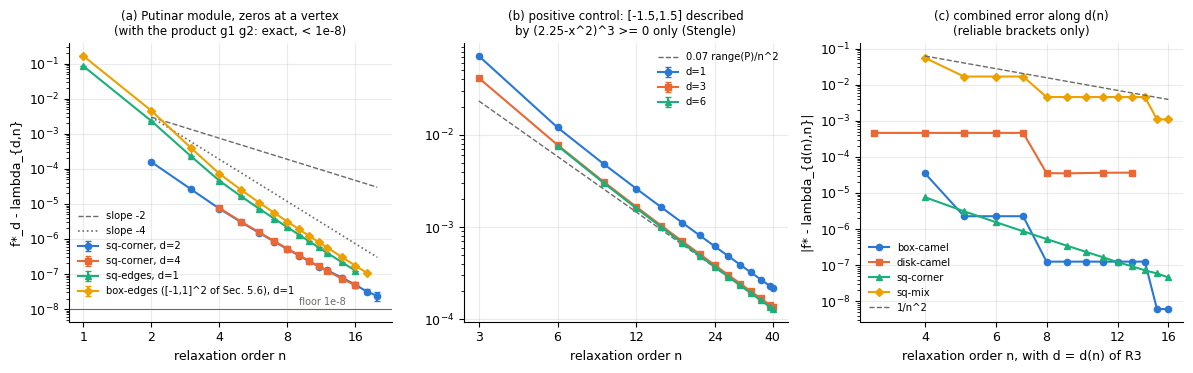

In [18]:
COL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]; MARK = ["o", "s", "^", "D"]; GREY = "#6b6a66"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "lines.linewidth": 1.5, "lines.markersize": 4.5, "legend.fontsize": 7.2})
from matplotlib.ticker import FixedLocator, NullLocator, FormatStrFormatter
def logx_ticks(a, ticks):
    a.xaxis.set_major_locator(FixedLocator(ticks)); a.xaxis.set_minor_locator(NullLocator())
    a.xaxis.set_major_formatter(FormatStrFormatter("%d"))
fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
def plot_series(a, key, d, v, i, label):
    S = [o for o in series(J, key, d, v) if np.isfinite(o["gap_lo"]) and o["gap_lo"] > FLOOR]
    if not S: return
    ns = np.array([o["n"] for o in S]); lo = np.array([o["gap_lo"] for o in S]); hi = np.array([o["gap_hi"] for o in S])
    a.errorbar(ns, 0.5 * (lo + hi), yerr=[0.5 * (hi - lo), 0.5 * (hi - lo)], color=COL[i], marker=MARK[i], label=label, capsize=2)
# (a) 2-D corner obstructions (Putinar module)
plot_series(ax[0], "sq-corner", 2, "Q", 0, "sq-corner, d=2")
plot_series(ax[0], "sq-corner", 4, "Q", 1, "sq-corner, d=4")
plot_series(ax[0], "sq-edges", 1, "Q", 2, "sq-edges, d=1")
plot_series(ax[0], "box-edges", 1, "Q", 3, "box-edges ([-1,1]^2 of §3.7), d=1")
nn = np.arange(2, 21)
ax[0].plot(nn, 3e-3 * (nn / 2.0) ** -2, "--", color=GREY, lw=1, label="slope -2")
ax[0].plot(nn, 3e-3 * (nn / 2.0) ** -4, ":", color=GREY, lw=1.2, label="slope -4")
ax[0].axhline(1e-8, color=GREY, lw=0.8); ax[0].text(9.0, 1.3e-8, "floor 1e-8", color=GREY, fontsize=7)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); logx_ticks(ax[0], [1, 2, 4, 8, 16])
ax[0].set_xlabel("relaxation order n"); ax[0].set_ylabel("f*_d - lambda_{d,n}")
ax[0].set_title("(a) Putinar module, zeros at a vertex\n(with the product g1 g2: exact, < 1e-8)", fontsize=8.5)
ax[0].legend(loc="lower left", bbox_to_anchor=(0.0, 0.06), frameon=False)
# (b) Stengle's description: the 1/n^2 control
for i, d in enumerate([1, 3, 6]):
    plot_series(ax[1], "1d-stengle", d, "Q", i, "d=%d" % d)
nn = np.arange(3, 41)
ax[1].plot(nn, 0.07 * 3.0 * nn ** -2.0, "--", color=GREY, lw=1, label="0.07 range(P)/n^2")
ax[1].set_xscale("log"); ax[1].set_yscale("log"); logx_ticks(ax[1], [3, 6, 12, 24, 40]); ax[1].set_xlabel("relaxation order n")
ax[1].set_title("(b) positive control: [-1.5,1.5] described\nby (2.25-x^2)^3 >= 0 only (Stengle)", fontsize=8.5)
ax[1].legend(loc="upper right", frameon=False)
# (c) combined rate along d(n), reliable brackets only
for i, key in enumerate(["box-camel", "disk-camel", "sq-corner", "sq-mix"]):
    pts = []
    for (k, d, n, v), o in J.items():
        if k == key and v == "Q" and d == d_of_n(PROBLEMS[k], n):
            m = load_meta(k, d); lo, hi = m["fstar"] - o["hi"], m["fstar"] - o["lo"]
            if np.isfinite(lo) and hi - lo <= 0.2 * abs(hi):
                pts.append((n, 0.5 * (lo + hi)))
    pts.sort()
    if pts:
        ax[2].plot([p[0] for p in pts], [p[1] for p in pts], color=COL[i], marker=MARK[i], label=key)
nn = np.arange(4, 17)
ax[2].plot(nn, 1.0 / nn ** 2, "--", color=GREY, lw=1, label="1/n^2")
ax[2].set_xscale("log"); ax[2].set_yscale("log"); logx_ticks(ax[2], [4, 6, 8, 12, 16])
ax[2].set_xlabel("relaxation order n, with d = d(n) of R3"); ax[2].set_ylabel("|f* - lambda_{d(n),n}|")
ax[2].set_title("(c) combined error along d(n)\n(reliable brackets only)", fontsize=8.5)
ax[2].legend(loc="lower left", frameon=False)
fig.tight_layout(); fig.savefig(os.path.join("..","figs","extra","rate_numerics.pdf"), bbox_inches="tight"); fig.savefig(os.path.join("..","figs","extra","rate_numerics.png"), dpi=130, bbox_inches="tight")
plt.show()

## 10. Figure for Theorem 13 (`thm:rate`): `../figs/fig_rate.pdf`

Two log-log panels. **(a)** The SoS term $f^\star_d-\lambda_{d,n}$ of (14a) at fixed $d=1$ against $n$: Stengle's degenerate
description $\{(2.25-x^2)^3\ge0\}$ of $[-1.5,1.5]$ with $q=2-x$ (`1d-stengle`; $f^\star_d=0.5/\theta_d(1.5)$, attained at the
boundary point where the generator vanishes to order three), the box $[-1,1]^2$ with the description of §3.7
($1-x_i^2\ge0$, $2-\|x\|^2\ge0$) and $q=(1-x_1)(1-x_2)$ (`box-edges`, cone `Q`; $f^\star_d=0$ on two edges through the vertex
$(1,1)$), and the same box with the product $(1-x_1^2)(1-x_2^2)\ge0$ added (cone `T`). **(b)** The combined error
$|\rho_{d(n),n}-f^\star|$ ($=|\lambda_{d(n),n}-f^\star|$: both lie in the bracket) along the coupling
$d(n)=\min\{d\ge\lceil\deg q/2\rceil:\varepsilon_d\le n^{-2}\}$ of (14c), for `sq-mix` (a global minimiser at the vertex $(1,1)$
of $[0,1]^2$, the point of $\mathcal X$ farthest from $0$, where the truncation error lives; SoS part exact),
`1d-stengle` (SoS part $\asymp n^{-2}$) and `box-edges` (truncation part $0$).

The brackets are those of Section 1 (same `job()` code). R4's cached entries in `bench_rate_results/` are reused; the new
ones are cached in `bench_rate_results/fig_rate/`, a separate folder so that the job set loaded by Sections 3–9 (which glob
`bench_rate_results/job_*.json`) and hence their outputs are unchanged. `fig_job` computes a missing entry (about 9 min on
4 processes, 34 CPU-min, for the whole section; the 2-D jobs at $n=19,20$ take 1.5–3.5 min each).

In [19]:
# Section 10a -- the jobs of the figure. R4's cached entries (bench_rate_results/) are reused; new ones are written to
# bench_rate_results/fig_rate/ by the same job() code, so the job set that Sections 3-9 glob is unchanged.
import shutil
RES_MAIN = RES
RES_FIG = os.path.join(RES_MAIN, "fig_rate")
os.makedirs(RES_FIG, exist_ok=True)

def _cached(fname):
    for folder in (RES_MAIN, RES_FIG):
        if os.path.exists(os.path.join(folder, fname)):
            return os.path.join(folder, fname)
    return None

def fig_meta(key, d):
    f = _cached("meta_%s_d%d.json" % (key, d))
    return json.load(open(f)) if f else None

def fig_job(key, d, n, v="Q", compute=True):
    """load (key, d, n, v) from either cache folder, or compute it with job() into bench_rate_results/fig_rate/"""
    global RES
    f = _cached("job_%s_d%d_n%d_%s.json" % (key, d, n, v))
    if f:
        return json.load(open(f))
    if not compute:
        return None
    mf = os.path.join(RES_MAIN, "meta_%s_d%d.json" % (key, d))
    if os.path.exists(mf) and not os.path.exists(os.path.join(RES_FIG, os.path.basename(mf))):
        shutil.copy(mf, RES_FIG)                      # same f*_d, f*, range(P) as R4's entry
    RES = RES_FIG
    try:
        return job(key, d, n, v)
    finally:
        RES = RES_MAIN

def gen_order(pb):
    # least n for which every generator enters Q_n (deg g_j <= 2n)
    return max(math.ceil(max(sum(a) for a in g) / 2) for g in pb.gs)

# (a) fixed d: Stengle's degenerate interval, and the box vertex with the description of §3.7 (Q) and with the product (T)
NS_STENGLE = list(range(3, 41)) + [45, 50, 55, 60, 70, 80]
FIG_FIXED = [("1d-stengle", d, n, "Q") for d in (1, 3, 6) for n in NS_STENGLE if n >= d]
FIG_FIXED += [("box-edges", 1, n, v) for v in ("Q", "T") for n in range(1, 21)]
FIG_FIXED += [("box-edges", 3, n, v) for v in ("Q", "T") for n in range(3, 19)]

# (b) along the coupling d(n) = min{d >= ceil(deg q/2) : eps_d <= n^-2} of (14c), for n >= max(d(n), gen_order)
COUPLING_NS = {"sq-mix": range(2, 21), "box-edges": range(2, 21), "1d-stengle": NS_STENGLE, "1d-multi": range(2, 81)}
def coupling_jobs(key):
    pb = PROBLEMS[key]
    return [(key, d_of_n(pb, n), n, "Q") for n in COUPLING_NS[key] if n >= max(d_of_n(pb, n), gen_order(pb))]
FIG_COUPLING = [a for key in COUPLING_NS for a in coupling_jobs(key)]

FIG_JOBS = list(dict.fromkeys(FIG_FIXED + FIG_COUPLING))
n_main = sum(1 for a in FIG_JOBS if os.path.exists(os.path.join(RES_MAIN, "job_%s_d%d_n%d_%s.json" % a)))
n_fig = sum(1 for a in FIG_JOBS if os.path.exists(os.path.join(RES_FIG, "job_%s_d%d_n%d_%s.json" % a)))
t0 = time.time()
JF = {a: fig_job(*a) for a in FIG_JOBS}
print("%d jobs: %d from R4's cache, %d from fig_rate/, %d computed now (%.1fs)" % (
    len(FIG_JOBS), n_main, n_fig, len(FIG_JOBS) - n_main - n_fig, time.time() - t0))
print("CPU time of the new entries (as recorded in their JSON): %.0f s" % sum(
    JF[a]["time"] for a in FIG_JOBS if not os.path.exists(os.path.join(RES_MAIN, "job_%s_d%d_n%d_%s.json" % a))))

349 jobs: 133 from R4's cache, 216 from fig_rate/, 0 computed now (0.0s)
CPU time of the new entries (as recorded in their JSON): 2038 s


### 10b. Fixed $d$: the series of panel (a) and their decay
Chord slopes are $\log(g(n_1)/g(n_2))/\log(n_2/n_1)$ with the range allowed by the brackets. Fits use the bracket midpoints of
the reliable points (width $\le20\%$ of the gap, lower end above the floor).

In [20]:
# Section 10b -- fixed d (panel (a)): the series, fitted power laws g ~ C n^-a, and chord slopes certified by the brackets
def fig_series(key, d, v):
    return sorted((o for a, o in JF.items() if a in set(FIG_FIXED) and a[:2] == (key, d) and a[3] == v), key=lambda o: o["n"])

def mid(o):
    return 0.5 * (o["gap_lo"] + o["gap_hi"])

def relw(o):
    return (o["gap_hi"] - o["gap_lo"]) / abs(mid(o)) if mid(o) != 0 else np.inf

def chord(S, n1, n2):
    # slope range of log g between n1 and n2 allowed by the brackets: [log(lo1/hi2), log(hi1/lo2)] / log(n2/n1)
    o1 = next(o for o in S if o["n"] == n1); o2 = next(o for o in S if o["n"] == n2)
    L = math.log(n2 / n1)
    return math.log(o1["gap_lo"] / o2["gap_hi"]) / L, math.log(0.5 * (o1["gap_lo"] + o1["gap_hi"]) / mid(o2)) / L, \
        math.log(o1["gap_hi"] / o2["gap_lo"]) / L

def fig_fit(key, d, v, nmin, nmax, rel=0.2):
    S = [o for o in fig_series(key, d, v) if nmin <= o["n"] <= nmax and reliable(o, rel)]
    ns = np.array([o["n"] for o in S], float)
    a, C, rms = fit_power(ns, np.array([mid(o) for o in S]))
    a_l = fit_power(ns, np.array([o["gap_lo"] for o in S]))[0]
    a_u = fit_power(ns, np.array([o["gap_hi"] for o in S]))[0]
    ch = chord(S, S[0]["n"], S[-1]["n"])
    rng = fig_meta(key, d)["Pmax"] - max(0.0, fig_meta(key, d)["Pmin"])
    return dict(key=key, d=d, v=v, n0=int(ns[0]), n1=int(ns[-1]), npts=len(S), a=a, C=C, rms=rms, a_lo=a_l, a_hi=a_u,
                chord=ch, first=S[0], last=S[-1], n2g=ns[-1] ** 2 * mid(S[-1]), n2g_range=ns[-1] ** 2 * mid(S[-1]) / rng, rngP=rng)

print("FLOOR = %.0e (an upper end below it counts as exact; brackets of width <= 20%% of the gap count as reliable)" % FLOOR)
for key, d, v in [("1d-stengle", 1, "Q"), ("1d-stengle", 3, "Q"), ("1d-stengle", 6, "Q"),
                  ("box-edges", 1, "Q"), ("box-edges", 1, "T"), ("box-edges", 3, "Q"), ("box-edges", 3, "T")]:
    S = fig_series(key, d, v)
    print("\n%s  d=%d  %s   (f*_d = %.12g, range(P_d) = %.4f)" % (key, d, v, fig_meta(key, d)["fsd"],
          fig_meta(key, d)["Pmax"] - max(0.0, fig_meta(key, d)["Pmin"])))
    print("   n   f*_d-hi       f*_d-lo       rel.width  n^2*mid    statuses")
    for o in S:
        print("  %2d  % .4e  % .4e  %9.1e  %9.3e  %s" % (o["n"], o["gap_lo"], o["gap_hi"],
              relw(o) if o["gap_hi"] > FLOOR else np.nan, o["n"] ** 2 * mid(o), o["status"]))

print("\nPower-law fits of the bracket midpoints (least squares in log; reliable points only)")
print("problem      d cone n-range (pts)  a      C        rms(dec)  a(lower ends) a(upper ends)  chord slope first->last "
      "[min, mid, max]   first gap    last gap     n^2 gap  n^2 gap/range(P) at the last n")
FITS = {}
for spec in [("1d-stengle", 1, "Q", 3, 80), ("1d-stengle", 1, "Q", 12, 40), ("1d-stengle", 1, "Q", 20, 80), ("1d-stengle", 1, "Q", 40, 80),
             ("1d-stengle", 3, "Q", 12, 40), ("1d-stengle", 3, "Q", 20, 80), ("1d-stengle", 6, "Q", 12, 40), ("1d-stengle", 6, "Q", 20, 80),
             ("box-edges", 1, "Q", 2, 20), ("box-edges", 1, "Q", 4, 20), ("box-edges", 1, "Q", 8, 20), ("box-edges", 1, "Q", 10, 20),
             ("box-edges", 3, "Q", 4, 18), ("box-edges", 3, "Q", 10, 18)]:
    F = FITS[spec] = fig_fit(*spec)
    print("%-12s %d %-4s %2d..%-2d (%2d)     %.3f  %.2e  %.4f    %.3f         %.3f          [%.3f, %.3f, %.3f]        %.3e    %.3e    %.3g    %.3g" % (
        F["key"], F["d"], F["v"], F["n0"], F["n1"], F["npts"], F["a"], F["C"], F["rms"], F["a_lo"], F["a_hi"], *F["chord"],
        mid(F["first"]), mid(F["last"]), F["n2g"], F["n2g_range"]))

print("\nLocal chord slopes of 1d-stengle (d=1) with their certified ranges [min, max]:")
S1 = fig_series("1d-stengle", 1, "Q")
for n1, n2 in [(3, 6), (6, 12), (12, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 70), (70, 80), (40, 80)]:
    lo_, m_, hi_ = chord(S1, n1, n2)
    print("   n = %2d -> %2d : slope %.3f  [%.3f, %.3f]" % (n1, n2, m_, lo_, hi_))
print("Local chord slopes of box-edges (d=1, Q):")
SB = fig_series("box-edges", 1, "Q")
for n1, n2 in [(2, 4), (4, 8), (8, 12), (12, 16), (16, 20), (18, 20)]:
    lo_, m_, hi_ = chord(SB, n1, n2)
    print("   n = %2d -> %2d : slope %.3f  [%.3f, %.3f]" % (n1, n2, m_, lo_, hi_))
for d in (1, 3):
    ST = [o for o in fig_series("box-edges", d, "T") if o["n"] >= 2]
    print("box-edges d=%d with the product (T), n = %d..%d: max upper end of f*_d - lambda_{d,n} = %.2e (n = %d), min lower end = %.2e" % (
        d, ST[0]["n"], ST[-1]["n"], max(o["gap_hi"] for o in ST), max(ST, key=lambda o: o["gap_hi"])["n"], min(o["gap_lo"] for o in ST)))
print("box-edges d=1 at n=1 (the product has degree 4 and does not enter Q_1): Q %.4e, T %.4e" % (
    mid(fig_series("box-edges", 1, "Q")[0]), mid(fig_series("box-edges", 1, "T")[0])))

FLOOR = 1e-08 (an upper end below it counts as exact; brackets of width <= 20% of the gap count as reliable)

1d-stengle  d=1  Q   (f*_d = 0.153846153846, range(P_d) = 3.0000)
   n   f*_d-hi       f*_d-lo       rel.width  n^2*mid    statuses
   3   7.1768e-02   7.1768e-02    1.4e-09  6.459e-01  NT+proj:optimal/NT:optimal
   4   3.2284e-02   3.2284e-02    4.1e-10  5.165e-01  NT+proj:optimal/NT:optimal
   5   1.8500e-02   1.8500e-02    7.7e-09  4.625e-01  NT+proj:optimal/NT:optimal
   6   1.2032e-02   1.2032e-02    9.5e-09  4.331e-01  NT+proj:optimal/NT:stalled
   7   8.4657e-03   8.4657e-03    1.6e-08  4.148e-01  NT+proj:optimal/NT:stalled
   8   6.2861e-03   6.2861e-03    4.4e-08  4.023e-01  NT+proj:tiny_step/NT:stalled
   9   4.8549e-03   4.8549e-03    7.2e-08  3.933e-01  NT+proj:tiny_step/NT:tiny_step
  10   3.8639e-03   3.8639e-03    6.2e-07  3.864e-01  NT+proj:tiny_step/NT:stalled
  11   3.1489e-03   3.1489e-03    3.2e-06  3.810e-01  NT+proj:tiny_step/NT:stalled
  12   2.6159e-03  

### 10c. Along the coupling $d(n)$ of (14c): the series of panel (b)
$f^\star-\lambda_{d,n}=(f^\star-f^\star_d)+(f^\star_d-\lambda_{d,n})$: truncation part plus SoS part. `f*-l_{d,n}` is the
error of the validated bound $\ell_{d,n}=\min_{\mathcal X}(\lambda\,\omega^2\theta_d)$ of (14b), computed from the certified lower end.

In [21]:
# Section 10c -- along the coupling d(n) of (14c) (panel (b)). With the ball constraint (sq-mix, box-edges, 1d-multi)
# lambda = rho (strong duality); in every case lo <= lambda_{d,n} <= rho_{d,n} <= hi, so f* - [hi, lo] contains both errors.
def ell(o, m):
    # validated bound l_{d,n} = min_X(lo omega^2 theta_d) from the certified lo (0 is in X for all four problems, where omega^2 theta_d = 1)
    return o["lo"] * (1 - m["eps_d"]) if o["lo"] >= 0 else o["lo"]

def coupling_series(key):
    out = []
    for a in coupling_jobs(key):
        o, m = JF[a], fig_meta(a[0], a[1])
        out.append(dict(n=a[2], d=a[1], eps=m["eps_d"], lo=m["fstar"] - o["hi"], hi=m["fstar"] - o["lo"],
                        trunc=m["fstar"] - m["fsd"], sos_lo=o["gap_lo"], sos_hi=o["gap_hi"], ell=m["fstar"] - ell(o, m), status=o["status"]))
    return out

COUP = {key: coupling_series(key) for key in COUPLING_NS}
for key, C in COUP.items():
    print("\n%s along d(n):  f* = %.12g" % (key, fig_meta(key, C[0]["d"])["fstar"]))
    print("   n  d(n)  eps_d      n^-2       f*-hi (lower)  f*-lo (upper)  f*-f*_d       f*_d-lambda (SoS) bracket     n^2*|err|  f*-l_{d,n}   statuses")
    for r in C:
        e = 0.5 * (r["lo"] + r["hi"])
        print("  %2d  %2d   %.3e  %.3e  % .4e    % .4e    % .4e   [% .3e, % .3e]  %8.4f  % .3e  %s" % (
            r["n"], r["d"], r["eps"], r["n"] ** -2.0, r["lo"], r["hi"], r["trunc"], r["sos_lo"], r["sos_hi"], r["n"] ** 2 * abs(e), r["ell"], r["status"]))

print("\nSummary along d(n) (midpoints; n^2*|err| over the listed n; power law fitted to the reliable points above the floor)")
CSUM = {}
for key, C in COUP.items():
    P = [r for r in C if r["lo"] > FLOOR and (r["hi"] - r["lo"]) <= 0.2 * r["lo"]]
    ns = np.array([r["n"] for r in P], float); es = np.array([0.5 * (r["lo"] + r["hi"]) for r in P])
    a, Cc, rms = fit_power(ns, es)
    k2 = ns ** 2 * es
    share = max(abs(r["trunc"]) / (0.5 * (r["lo"] + r["hi"])) for r in P)   # truncation share of the error
    CSUM[key] = dict(n0=int(ns[0]), n1=int(ns[-1]), npts=len(P), a=a, C=Cc, rms=rms, k2min=k2.min(), k2max=k2.max(),
                     n_k2min=int(ns[k2.argmin()]), n_k2max=int(ns[k2.argmax()]), first=es[0], last=es[-1], ds=sorted(set(r["d"] for r in C)))
    print("%-10s n = %d..%d (%d pts), d(n) = %s: |err| %.3e -> %.3e; n^2|err| in [%.3g (n=%d), %.3g (n=%d)]; fitted slope %.3f (C = %.3g, rms %.3f dec); "
          "max |f*-f*_d| / |err| = %.3f" % (key, ns[0], ns[-1], len(P), CSUM[key]["ds"], es[0], es[-1], k2.min(), ns[k2.argmin()], k2.max(),
                                            ns[k2.argmax()], a, Cc, rms, share))


sq-mix along d(n):  f* = -1
   n  d(n)  eps_d      n^-2       f*-hi (lower)  f*-lo (upper)  f*-f*_d       f*_d-lambda (SoS) bracket     n^2*|err|  f*-l_{d,n}   statuses
   4   4   5.265e-02  6.250e-02   5.5579e-02     5.5579e-02     5.5579e-02   [-1.005e-11,  2.018e-12]    0.8893   5.558e-02  NT+proj:optimal/NT:optimal
   5   5   1.656e-02  4.000e-02   1.6843e-02     1.6843e-02     1.6843e-02   [-3.037e-12,  9.703e-14]    0.4211   1.684e-02  NT+proj:optimal/NT:optimal
   6   5   1.656e-02  2.778e-02   1.6843e-02     1.6843e-02     1.6843e-02   [-5.341e-11,  2.033e-12]    0.6063   1.684e-02  NT+proj:optimal/NT:optimal
   7   5   1.656e-02  2.041e-02   1.6843e-02     1.6843e-02     1.6843e-02   [-1.322e-10,  1.039e-11]    0.8253   1.684e-02  NT+proj:optimal/NT:optimal
   8   6   4.534e-03  1.562e-02   4.5545e-03     4.5545e-03     4.5545e-03   [-2.780e-12,  4.392e-13]    0.2915   4.554e-03  NT+proj:optimal/NT:optimal
   9   6   4.534e-03  1.235e-02   4.5545e-03     4.5545e-03     4.5545

### 10d. The figure

saved ../figs/fig_rate.pdf
(a): d = 1; n^-2 line through 1d-stengle at n = 3 (7.1768e-02); n = 3..80 (1d-stengle), 2..20 (box, Q; lower end above the floor), 2..20 (box, T, on the floor line)
(b): n^-2 line through sq-mix at n = 14 (4.5545e-03); n = 4..20 (sq-mix), 5..80 (1d-stengle)


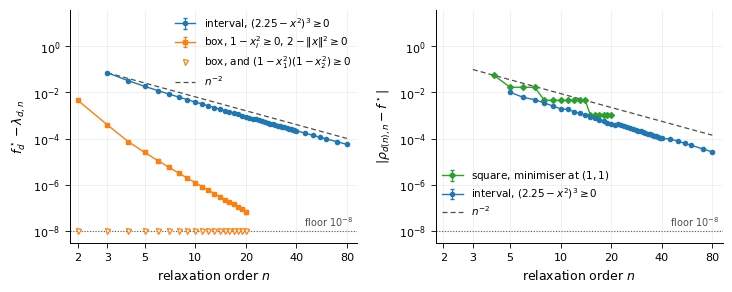

In [22]:
# Section 10d -- the paper's figure figs/fig_rate.pdf (no titles; panels (a), (b) named in the caption)
from matplotlib.ticker import FixedLocator, NullLocator, FixedFormatter
FIG_REF_A = ("1d-stengle", 1, 3)           # the n^-2 line of (a) passes through this point (bracket midpoint) ...
FIG_REF_B = ("sq-mix", 14)                 # ... and that of (b) through this one (the largest n^2 |error| of sq-mix)
COLS = {"1d-stengle": "C0", "box-edges": "C1", "sq-mix": "C2"}
MRK = {"1d-stengle": "o", "box-edges": "s", "sq-mix": "D"}
LAB = {"1d-stengle": r"interval, $(2.25-x^2)^3\geq0$", "box-edges": r"box, $1-x_i^2\geq0$, $2-\|x\|^2\geq0$",
       "box-T": r"box, and $(1-x_1^2)(1-x_2^2)\geq0$", "sq-mix": r"square, minimiser at $(1,1)$"}

def _bars(ax, ns, lo, hi, key, label):
    ns, lo, hi = (np.asarray(t, float) for t in (ns, lo, hi))
    m = 0.5 * (lo + hi)
    return ax.errorbar(ns, m, yerr=[m - lo, hi - m], color=COLS[key], marker=MRK[key], ms=3.0, lw=1.0, elinewidth=0.8,
                       capsize=1.6, label=label, zorder=3)

def fig_rate(path):
    rc = {"font.size": 9, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7.5,
          "axes.linewidth": 0.7, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
          "grid.linewidth": 0.5, "legend.frameon": False, "legend.handlelength": 2.0, "legend.borderaxespad": 0.2,
          "legend.labelspacing": 0.3, "xtick.major.width": 0.6, "ytick.major.width": 0.6}
    with plt.rc_context(rc):
        fig, axs = plt.subplots(1, 2, figsize=(7.2, 2.8))
        ax = axs[0]                                           # (a) fixed d = 1
        H = []
        S = [o for o in fig_series("1d-stengle", 1, "Q") if o["gap_lo"] > FLOOR]
        H.append(_bars(ax, [o["n"] for o in S], [o["gap_lo"] for o in S], [o["gap_hi"] for o in S], "1d-stengle", LAB["1d-stengle"]))
        S = [o for o in fig_series("box-edges", 1, "Q") if o["gap_lo"] > FLOOR and o["n"] >= 2]
        H.append(_bars(ax, [o["n"] for o in S], [o["gap_lo"] for o in S], [o["gap_hi"] for o in S], "box-edges", LAB["box-edges"]))
        S = [o for o in fig_series("box-edges", 1, "T") if o["n"] >= 2]
        assert all(o["gap_hi"] < FLOOR for o in S)            # exact to the floor: drawn on the floor line
        H += ax.plot([o["n"] for o in S], [FLOOR] * len(S), ls="none", marker="v", ms=3.6, mfc="white", mec=COLS["box-edges"],
                     mew=0.9, label=LAB["box-T"], zorder=4)
        g0 = mid(JF[(FIG_REF_A[0], FIG_REF_A[1], FIG_REF_A[2], "Q")])
        nn = np.array([FIG_REF_A[2], 80.0])
        H += ax.plot(nn, g0 * (nn / FIG_REF_A[2]) ** -2.0, ls=(0, (4, 2.5)), color="0.3", lw=0.9, label=r"$n^{-2}$", zorder=2)
        ax.set_ylabel(r"$f^\star_d-\lambda_{d,n}$")
        ax.legend(handles=H, loc="upper right")
        ax = axs[1]                                           # (b) along d(n)
        H = []
        for key in ("sq-mix", "1d-stengle"):
            C = [r for r in COUP[key] if r["lo"] > FLOOR]
            H.append(_bars(ax, [r["n"] for r in C], [r["lo"] for r in C], [r["hi"] for r in C], key, LAB[key]))
        r = next(r for r in COUP[FIG_REF_B[0]] if r["n"] == FIG_REF_B[1])
        nn = np.array([3.0, 80.0])
        H += ax.plot(nn, 0.5 * (r["lo"] + r["hi"]) * (nn / FIG_REF_B[1]) ** -2.0, ls=(0, (4, 2.5)), color="0.3", lw=0.9,
                     label=r"$n^{-2}$", zorder=2)
        ax.set_ylabel(r"$|\rho_{d(n),n}-f^\star|$")
        ax.legend(handles=H, loc="lower left", bbox_to_anchor=(0.0, 0.08))
        for ax in axs:
            ax.axhline(FLOOR, color="0.3", lw=0.8, ls=(0, (1, 1.5)), zorder=1)
            ax.text(88, FLOOR * 1.3, r"floor $10^{-8}$", ha="right", va="bottom", fontsize=7, color="0.3")
            ax.set_xscale("log"); ax.set_yscale("log")
            ax.set_xlim(1.8, 92); ax.set_ylim(3e-9, 40.0)
            ax.xaxis.set_major_locator(FixedLocator([2, 3, 5, 10, 20, 40, 80])); ax.xaxis.set_minor_locator(NullLocator())
            ax.xaxis.set_major_formatter(FixedFormatter(["2", "3", "5", "10", "20", "40", "80"]))
            ax.yaxis.set_major_locator(FixedLocator([1e-8, 1e-6, 1e-4, 1e-2, 1e0])); ax.yaxis.set_minor_locator(NullLocator())
            ax.set_xlabel(r"relaxation order $n$")
        fig.tight_layout(pad=0.3, w_pad=1.5)
        fig.savefig(path, bbox_inches="tight", pad_inches=0.02)
    print("saved", path)
    return fig

fig = fig_rate(os.path.join("..", "figs", "fig_rate.pdf"))
print("(a): d = 1; n^-2 line through %s at n = %d (%.4e); n = %d..%d (1d-stengle), %d..%d (box, Q; lower end above the floor), "
      "%d..%d (box, T, on the floor line)" % (FIG_REF_A[0], FIG_REF_A[2], mid(JF[(FIG_REF_A[0], FIG_REF_A[1], FIG_REF_A[2], "Q")]),
      fig_series("1d-stengle", 1, "Q")[0]["n"], fig_series("1d-stengle", 1, "Q")[-1]["n"], 2,
      max(o["n"] for o in fig_series("box-edges", 1, "Q") if o["gap_lo"] > FLOOR), 2, fig_series("box-edges", 1, "T")[-1]["n"]))
print("(b): n^-2 line through %s at n = %d (%.4e); n = %d..%d (sq-mix), %d..%d (1d-stengle)" % (
    FIG_REF_B[0], FIG_REF_B[1], next(0.5 * (r["lo"] + r["hi"]) for r in COUP[FIG_REF_B[0]] if r["n"] == FIG_REF_B[1]),
    COUP["sq-mix"][0]["n"], COUP["sq-mix"][-1]["n"], COUP["1d-stengle"][0]["n"], COUP["1d-stengle"][-1]["n"]))
plt.show()

### 10e. Numbers for the caption and the text

In [23]:
# Section 10e -- every number the caption of fig_rate or the text of §3.6 may quote, from the cells above
print("floor: %.0e" % FLOOR)
for spec in [("1d-stengle", 1, "Q", 12, 40), ("1d-stengle", 1, "Q", 20, 80), ("1d-stengle", 3, "Q", 20, 80), ("1d-stengle", 6, "Q", 20, 80),
             ("box-edges", 1, "Q", 4, 20), ("box-edges", 1, "Q", 10, 20), ("box-edges", 3, "Q", 4, 18)]:
    F = FITS[spec]
    print("(a) %-10s d=%d %s: slope %.2f on n = %d..%d (%d reliable points, rms %.3f decades; lower/upper ends %.2f/%.2f); "
          "gap %.2e at n=%d, %.2e at n=%d; n^2 gap = %.3g = %.3g range(P_d)" % (
          F["key"], F["d"], F["v"], F["a"], F["n0"], F["n1"], F["npts"], F["rms"], F["a_lo"], F["a_hi"], mid(F["first"]), F["n0"],
          mid(F["last"]), F["n1"], F["n2g"], F["n2g_range"]))
S = fig_series("box-edges", 1, "Q")
wide = [o for o in S if o["gap_lo"] > FLOOR and not reliable(o)]
print("(a) box-edges d=1 Q: brackets wider than 20%%: %s" % ", ".join("n=%d [%.2e, %.2e]" % (o["n"], o["gap_lo"], o["gap_hi"]) for o in wide))
S1 = fig_series("1d-stengle", 1, "Q")
print("(a) 1d-stengle d=1: widest relative bracket %.1f%% (n=%d); first %.4e (n=3), last [%.3e, %.3e] (n=80)" % (
    100 * max(relw(o) for o in S1), max(S1, key=relw)["n"], mid(S1[0]), S1[-1]["gap_lo"], S1[-1]["gap_hi"]))
for d in (1, 3):
    ST = [o for o in fig_series("box-edges", d, "T") if o["n"] >= 2]
    print("(a) box-edges d=%d with the product: f*_d - lambda_{d,n} <= %.1e for n = %d..%d (exact at n = d to the floor)" % (
        d, max(o["gap_hi"] for o in ST), ST[0]["n"], ST[-1]["n"]))
for key in COUP:
    s = CSUM[key]
    print("(b) %-10s n = %d..%d, d(n) = %d..%d: error %.2e -> %.2e, n^2 error in [%.3g, %.3g], fitted slope %.2f (rms %.3f dec)" % (
        key, s["n0"], s["n1"], s["ds"][0], s["ds"][-1], s["first"], s["last"], s["k2min"], s["k2max"], s["a"], s["rms"]))
M = COUP["sq-mix"]
print("(b) sq-mix: SoS part |f*_d - lambda| <= %.1e at every n (so the error is f* - f*_{d(n)} = e^2/theta_d(2) - 1)" % max(
    max(abs(r["sos_lo"]), abs(r["sos_hi"])) for r in M))
St = COUP["1d-stengle"]
print("(b) 1d-stengle: truncation part f* - f*_d / error in [%.3f, %.3f] (opposite signs: f* > 0)" % (
    min(r["trunc"] / (0.5 * (r["lo"] + r["hi"])) for r in St), max(r["trunc"] / (0.5 * (r["lo"] + r["hi"])) for r in St)))

floor: 1e-08
(a) 1d-stengle d=1 Q: slope 2.06 on n = 12..40 (29 reliable points, rms 0.002 decades; lower/upper ends 2.06/2.06); gap 2.62e-03 at n=12, 2.18e-04 at n=40; n^2 gap = 0.348 = 0.116 range(P_d)
(a) 1d-stengle d=1 Q: slope 2.01 on n = 20..80 (27 reliable points, rms 0.004 decades; lower/upper ends 2.04/1.98); gap 8.98e-04 at n=20, 5.57e-05 at n=80; n^2 gap = 0.356 = 0.119 range(P_d)
(a) 1d-stengle d=3 Q: slope 2.03 on n = 20..80 (27 reliable points, rms 0.003 decades; lower/upper ends 2.05/2.01); gap 5.65e-04 at n=20, 3.41e-05 at n=80; n^2 gap = 0.219 = 0.0728 range(P_d)
(a) 1d-stengle d=6 Q: slope 2.04 on n = 20..80 (27 reliable points, rms 0.003 decades; lower/upper ends 2.05/2.03); gap 5.41e-04 at n=20, 3.20e-05 at n=80; n^2 gap = 0.205 = 0.0678 range(P_d)
(a) box-edges  d=1 Q: slope 4.29 on n = 4..18 (15 reliable points, rms 0.020 decades; lower/upper ends 4.31/4.27); gap 7.29e-05 at n=4, 1.07e-07 at n=18; n^2 gap = 3.48e-05 = 8.69e-06 range(P_d)
(a) box-edges  d=1 Q: slop